
# HindCast_Rev1 — PLOS ONE Revision Notebook

**Purpose.** This notebook implements all methodological updates requested by the editor/reviewer:
1) **Alignment with Cabañuelas practice:** day→month mapping for days 1–12 and **reverse mapping** for days 13–24; analyses recomputed using these **day-specific predictors**.
2) **Detrending to isolate interannual skill:** per-department linear (OLS) and robust (Theil–Sen) detrending; anomalies vs. climatology; side-by-side results (raw vs. detrended).
3) **Data quality and missing data procedures:** transparent summaries of missingness, filtering rules, and optional simple imputations (explicit, reproducible).
4) **RMSE verification and units:** checks of physical units and ranges; sanity plots and scale diagnostics.

The notebook exports **CSV tables** and **figures**.


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# === Paths ===
DATA_LONG_PATH = Path('data/DataAllMining_Imputed2.csv')  
OUTDIR = Path('data/outputs_hindcast')
OUTDIR.mkdir(parents=True, exist_ok=True)

# Random seed for reproducibility
RNG_SEED = 42
np.random.seed(RNG_SEED)

print('Using data:', DATA_LONG_PATH)
print('Outputs ->', OUTDIR)


Using data: data/DataAllMining_Imputed2.csv
Outputs -> data/outputs_hindcast


## 1. Load data and standardise column names

In [2]:
df = pd.read_csv(DATA_LONG_PATH)

In [3]:
print(df)

      Unnamed: 0  cat__Departamento_AMAZONAS  cat__Departamento_ANTIOQUIA  \
0              0                         1.0                          0.0   
1              1                         1.0                          0.0   
2              2                         1.0                          0.0   
3              3                         1.0                          0.0   
4              4                         1.0                          0.0   
...          ...                         ...                          ...   
7118        7118                         0.0                          0.0   
7119        7119                         0.0                          0.0   
7120        7120                         0.0                          0.0   
7121        7121                         0.0                          0.0   
7122        7122                         0.0                          0.0   

      cat__Departamento_ARAUCA  cat__Departamento_ATLANTICO  \
0           

In [4]:
df.columns

Index(['Unnamed: 0', 'cat__Departamento_AMAZONAS',
       'cat__Departamento_ANTIOQUIA', 'cat__Departamento_ARAUCA',
       'cat__Departamento_ATLANTICO', 'cat__Departamento_BOGOTA',
       'cat__Departamento_BOLIVAR', 'cat__Departamento_BOYACA',
       'cat__Departamento_CALDAS', 'cat__Departamento_CAQUETA',
       'cat__Departamento_CASANARE', 'cat__Departamento_CAUCA',
       'cat__Departamento_CESAR', 'cat__Departamento_CHOCO',
       'cat__Departamento_CORDOBA', 'cat__Departamento_CUNDINAMARCA',
       'cat__Departamento_GUAINIA', 'cat__Departamento_GUAVIARE',
       'cat__Departamento_HUILA', 'cat__Departamento_LA GUAJIRA',
       'cat__Departamento_MAGDALENA', 'cat__Departamento_META',
       'cat__Departamento_NARINO', 'cat__Departamento_NORTE DE SANTANDER',
       'cat__Departamento_PUTUMAYO', 'cat__Departamento_QUINDIO',
       'cat__Departamento_RISARALDA',
       'cat__Departamento_SAN ANDRES PROVIDENCIA',
       'cat__Departamento_SANTANDER', 'cat__Departamento_SUCRE',
   

In [5]:
df

,Unnamed: 0,cat__Departamento_AMAZONAS,cat__Departamento_ANTIOQUIA,cat__Departamento_ARAUCA,cat__Departamento_ATLANTICO,cat__Departamento_BOGOTA,cat__Departamento_BOLIVAR,cat__Departamento_BOYACA,cat__Departamento_CALDAS,cat__Departamento_CAQUETA,...,num__Rain_day_prim,num__Temp_day_prim,num__Humi_day_prim,num__Rain_day_sec,num__Temp_day_sec,num__Humi_day_sec,num__Rain_day_avg,num__Temp_day_avg,num__Humi_day_avg,Departamento
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,62.895832,20.833943,74.128622,17.644233,21.336949,71.061081,39.941676,21.084990,72.607614,AMAZONAS
1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,26.955170,21.749081,73.859745,25.292943,21.678551,71.679886,27.136276,21.770086,72.658104,AMAZONAS
2,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,26.955170,21.749081,73.859745,25.292943,21.678551,71.679886,27.136276,21.770086,72.672973,AMAZONAS
3,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,26.955170,21.749081,73.859745,25.292943,21.678551,71.679886,27.136276,21.770086,72.672973,AMAZONAS
4,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,26.955170,21.749081,73.859745,25.292943,21.678551,71.679886,27.136276,21.768943,72.672973,AMAZONAS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7118,7118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,21.751477,71.479631,0.000000,22.374877,72.446923,0.000000,22.013316,72.385756,VICHADA
7119,7119,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,21.764601,71.479631,0.000000,22.374877,72.446923,0.000000,22.013316,72.385756,VICHADA
7120,7120,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,21.764601,71.479631,0.000000,22.374877,72.446923,0.000000,22.013316,72.385756,VICHADA
7121,7121,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,21.764601,71.479631,0.000000,22.374877,72.446923,0.000000,22.013316,72.385756,VICHADA


# 1. HindCast study....

## 1.1. Preparing framework and pipeline...

In [6]:
# df exists in memory
YEAR_COL = "num__Year"
MONTH_COL = "num__Month"
DEPT_COL = "Departamento"

TARGETS = {
    "RAIN": "num__Rain_month",
    "TEMP": "num__Temp_month",
    "HUMI": "num__Humi_month",
}

# Feature-sets:
FEATURE_SETS = {
    "PRIMARY_1_12":  ["num__Rain_day_prim", "num__Temp_day_prim", "num__Humi_day_prim"],
    "SECONDARY_13_24":["num__Rain_day_sec",  "num__Temp_day_sec",  "num__Humi_day_sec"],
    "AVG":           ["num__Rain_day_avg",  "num__Temp_day_avg",  "num__Humi_day_avg"],
    "PRIMARY+SECONDARY": [
        "num__Rain_day_prim","num__Temp_day_prim","num__Humi_day_prim",
        "num__Rain_day_sec","num__Temp_day_sec","num__Humi_day_sec"
    ],
}

# ¿Include one-hot by Departamento like features? (optional)
INCLUDE_DEPT_DUMMIES = True   
DEPT_DUMMY_PREFIX = "cat__Departamento_"

# Objetive months (normally 2..12)
MONTHS = list(range(2, 13))

RANDOM_STATE = 0

MODELS = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))
    ]),
    "RF": RandomForestRegressor(
        n_estimators=300, max_depth=6, min_samples_leaf=2,
        bootstrap=True, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "HGB": HistGradientBoostingRegressor(
        max_depth=3, learning_rate=0.1, l2_regularization=0.0,
        random_state=RANDOM_STATE
    )
}

In [7]:
def _safe_rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def _make_persistence(df_sub, target_col):
    """
    Persistence baseline: y_hat(m) = y(m-1) dentro de (Departamento, Year).
    """
    tmp = df_sub[[DEPT_COL, YEAR_COL, MONTH_COL, target_col]].copy()
    tmp = tmp.sort_values([DEPT_COL, YEAR_COL, MONTH_COL])
    tmp["y_persist"] = tmp.groupby([DEPT_COL, YEAR_COL])[target_col].shift(1)
    return tmp[["y_persist"]]

def _baseline_global_clim(train_y):
    return float(np.nanmean(train_y))

def _baseline_dept_clim(train_df, target_col):
    # media por depto en TRAIN
    return train_df.groupby(DEPT_COL)[target_col].mean()

def loy_o_predict(
    df_base: pd.DataFrame,
    month: int,
    target_col: str,
    feature_cols: list[str],
    detrend_target: bool = False
):
    """
    LOY-O para un mes específico.
    Devuelve:
      - pred_df con y_true, preds por modelo, baselines, año, dept
      - global_metrics df (por modelo/baseline)
      - per_year_metrics df (RMSE por año por modelo/baseline)
    """
    # 1) Filtrar mes
    d = df_base[df_base[MONTH_COL] == month].copy()

    # 2) Features + target + keys
    cols_needed = [DEPT_COL, YEAR_COL, MONTH_COL, target_col] + feature_cols
    if INCLUDE_DEPT_DUMMIES:
        dept_dum_cols = [c for c in d.columns if c.startswith(DEPT_DUMMY_PREFIX)]
        cols_needed += dept_dum_cols
    else:
        dept_dum_cols = []

    d = d[cols_needed].copy()

    # 3) Drop NA en target
    d = d.dropna(subset=[target_col])

    # 4) Drop NA en features (si quieres más permisivo, puedes imputar)
    d = d.dropna(subset=feature_cols)

    # 5) persistence baseline (requiere df original con todos los meses; aquí ya es un solo mes,
    #    así que para persistencia usamos df_base completo y luego alineamos por dept-year-month)
    pers = _make_persistence(df_base, target_col)
    pers = pd.concat([df_base[[DEPT_COL, YEAR_COL, MONTH_COL]].reset_index(drop=True), pers], axis=1)
    pers = pers[pers[MONTH_COL] == month][[DEPT_COL, YEAR_COL, "y_persist"]].copy()

    d = d.merge(pers, on=[DEPT_COL, YEAR_COL], how="left")

    # 6) LOY-O
    years = sorted(d[YEAR_COL].unique())
    rows = []

    for yout in years:
        train = d[d[YEAR_COL] != yout].copy()
        test  = d[d[YEAR_COL] == yout].copy()

        if len(test) == 0 or len(train) == 0:
            continue

        # --- Baselines ---
        # Global climatology (fold mean)
        mu_global = _baseline_global_clim(train[target_col].values)
        test["pred_GlobalClim"] = mu_global

        # Dept climatology (fold mean within department)
        mu_dept = _baseline_dept_clim(train, target_col)
        test["pred_DeptClim"] = test[DEPT_COL].map(mu_dept)

        # Persistence (y(m-1))
        test["pred_Persist"] = test["y_persist"]

        # --- Optional: detrend target (fit per dept on TRAIN only, apply to TRAIN+TEST) ---
        # (esto NO toca los baselines, solo el entrenamiento de ML y su evaluación si lo activas)
        if detrend_target:
            # fit slope/intercept per dept using TRAIN
            train["_y"] = train[target_col].astype(float)
            test["_y"]  = test[target_col].astype(float)

            # parámetros por depto
            params = {}
            for dep, g in train.groupby(DEPT_COL):
                x = g[YEAR_COL].values.astype(float)
                yy = g["_y"].values
                if len(np.unique(x)) < 2:
                    # sin variación temporal, no se puede ajustar tendencia
                    params[dep] = (0.0, np.nanmean(yy))
                else:
                    b, a = np.polyfit(x, yy, 1)  # yy ≈ b*x + a
                    params[dep] = (b, a)

            def detrend_series(df_):
                yy = df_["_y"].values.astype(float)
                x  = df_[YEAR_COL].values.astype(float)
                dep = df_[DEPT_COL].values
                pred = np.array([params[d0][0]*x[i] + params[d0][1] for i, d0 in enumerate(dep)], dtype=float)
                return yy - pred

            y_train = detrend_series(train)
            y_test  = detrend_series(test)
        else:
            y_train = train[target_col].values.astype(float)
            y_test  = test[target_col].values.astype(float)

        # --- ML models ---
        X_train = train[feature_cols + dept_dum_cols].values
        X_test  = test[feature_cols + dept_dum_cols].values

        for mname, model in MODELS.items():
            mdl = model
            mdl.fit(X_train, y_train)
            yhat = mdl.predict(X_test)
            test[f"pred_{mname}"] = yhat

        # guardar
        test["_y_true_eval"] = y_test  # (posiblemente detrended)
        rows.append(test[[DEPT_COL, YEAR_COL, MONTH_COL, target_col, "_y_true_eval",
                          "pred_GlobalClim","pred_DeptClim","pred_Persist"] +
                         [f"pred_{k}" for k in MODELS.keys()]])

    pred_df = pd.concat(rows, ignore_index=True)

    # 7) Métricas globales (sobre y_eval)
    y = pred_df["_y_true_eval"].values
    out_rows = []

    # baselines + modelos
    all_preds = {
        "GlobalClim": pred_df["pred_GlobalClim"].values,
        "DeptClim":   pred_df["pred_DeptClim"].values,
        "Persist":    pred_df["pred_Persist"].values,
        **{name: pred_df[f"pred_{name}"].values for name in MODELS.keys()}
    }

    # Nota: Persist puede tener NaN (si no hay mes previo); filtramos caso a caso
    for name, yp in all_preds.items():
        mask = np.isfinite(y) & np.isfinite(yp)
        rmse = _safe_rmse(y[mask], yp[mask])
        r2   = float(r2_score(y[mask], yp[mask]))
        out_rows.append({"Model": name, "RMSE": rmse, "R2": r2, "Month": month})

    global_metrics = pd.DataFrame(out_rows).sort_values("RMSE")

    # 8) RMSE por año (para tus tablas por año)
    per_year = []
    for yy in sorted(pred_df[YEAR_COL].unique()):
        sub = pred_df[pred_df[YEAR_COL] == yy]
        y0 = sub["_y_true_eval"].values
        for name, yp in all_preds.items():
            yp0 = (sub[f"pred_{name}"].values if name in MODELS else sub[f"pred_{name}"].values) \
                  if f"pred_{name}" in sub.columns else None
            if yp0 is None:
                continue
            mask = np.isfinite(y0) & np.isfinite(yp0)
            if mask.sum() == 0:
                continue
            per_year.append({"Year": yy, "Model": name, "RMSE": _safe_rmse(y0[mask], yp0[mask]), "Month": month})

    per_year_metrics = pd.DataFrame(per_year)

    return pred_df, global_metrics, per_year_metrics

In [8]:
def run_multi_month(
    df_base: pd.DataFrame,
    target_name: str,
    target_col: str,
    feature_set_name: str,
    feature_cols: list[str],
    detrend_target: bool = False
):
    all_global = []
    all_per_year = []
    all_preds = []

    for m in MONTHS:
        pred_df, gm, pym = loy_o_predict(
            df_base=df_base,
            month=m,
            target_col=target_col,
            feature_cols=feature_cols,
            detrend_target=detrend_target
        )
        pred_df["Target"] = target_name
        pred_df["FeatureSet"] = feature_set_name
        gm["Target"] = target_name
        gm["FeatureSet"] = feature_set_name
        pym["Target"] = target_name
        pym["FeatureSet"] = feature_set_name

        all_preds.append(pred_df)
        all_global.append(gm)
        all_per_year.append(pym)

    pred_all = pd.concat(all_preds, ignore_index=True)
    global_all = pd.concat(all_global, ignore_index=True)
    per_year_all = pd.concat(all_per_year, ignore_index=True)

    return pred_all, global_all, per_year_all


def plot_rmse_bars(global_metrics_df, target_name, feature_set_name, outpath):
    # agrego RMSE promedio a través de meses
    g = global_metrics_df.groupby("Model")["RMSE"].mean().sort_values()
    plt.figure(figsize=(8,6))
    plt.bar(g.index, g.values)
    plt.title(f"Hindcast skill (LOY-O) — {target_name} — {feature_set_name}", fontsize=14)
    plt.ylabel("Global RMSE (units of variable)", fontsize=12)
    plt.xticks(rotation=0, fontsize=12); plt.yticks(rotation=0, fontsize=12)
    plt.tight_layout()
    plt.savefig(outpath, dpi=220)
    plt.show()

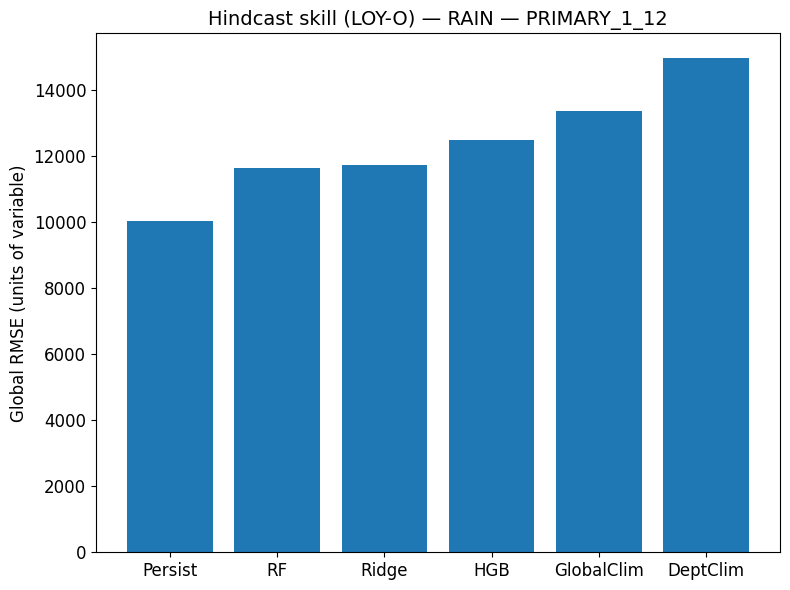

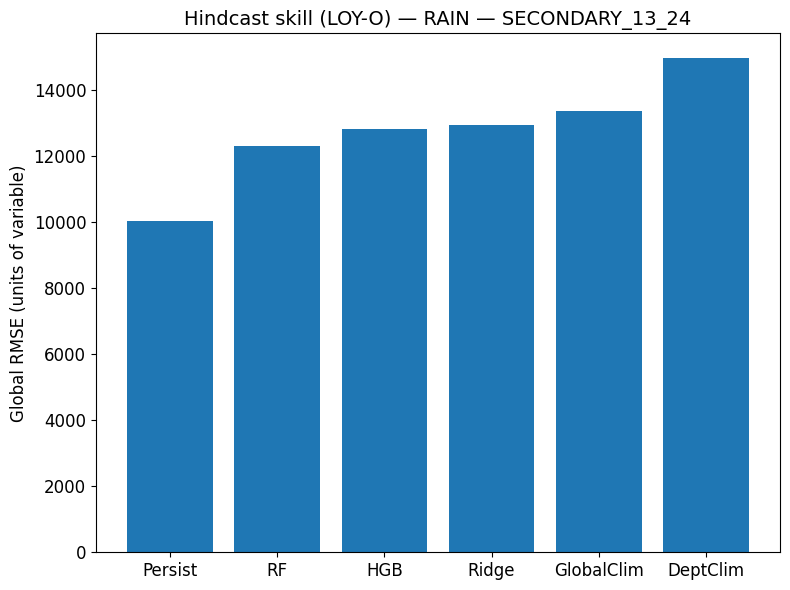

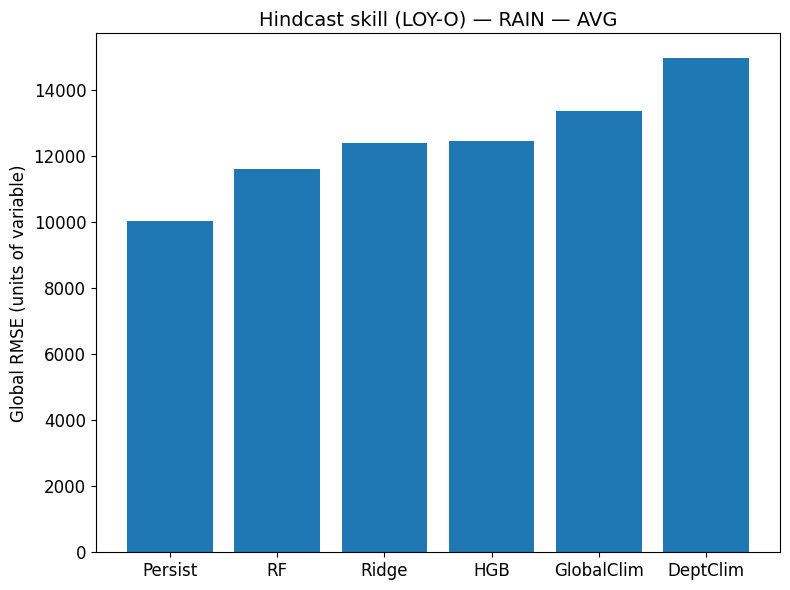

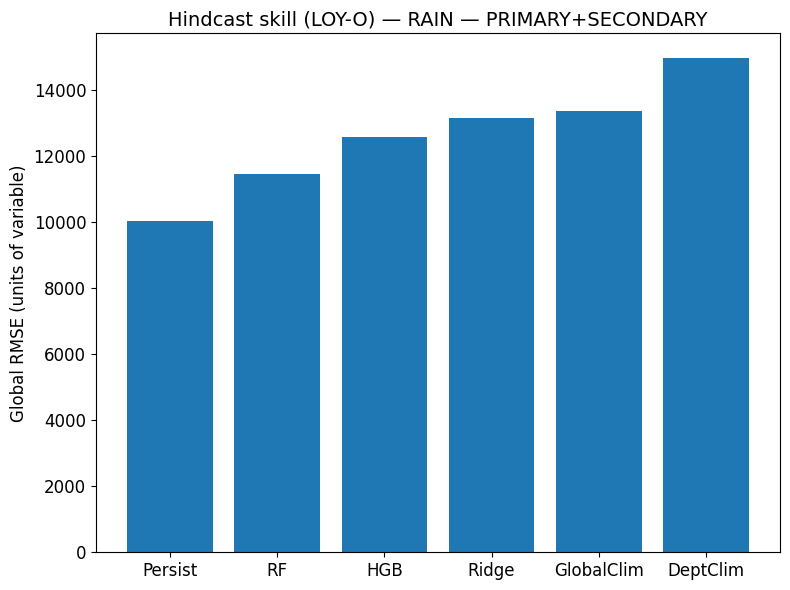

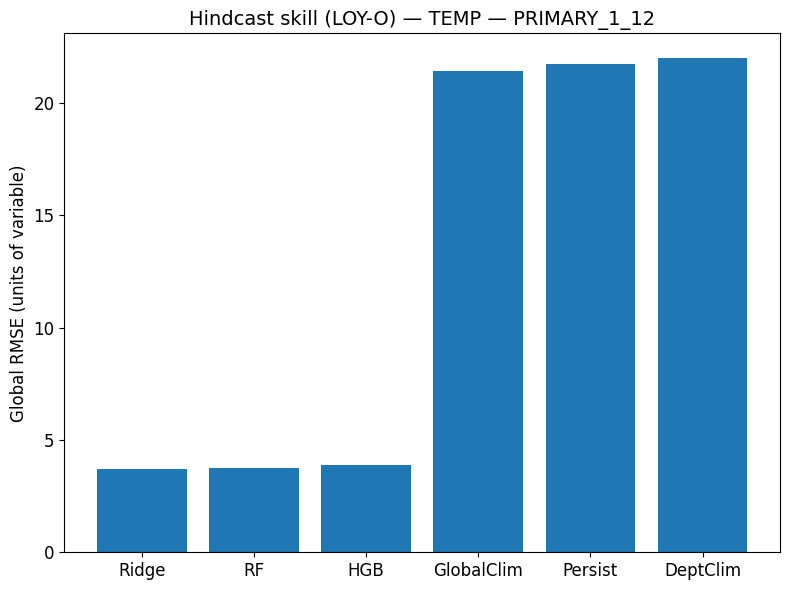

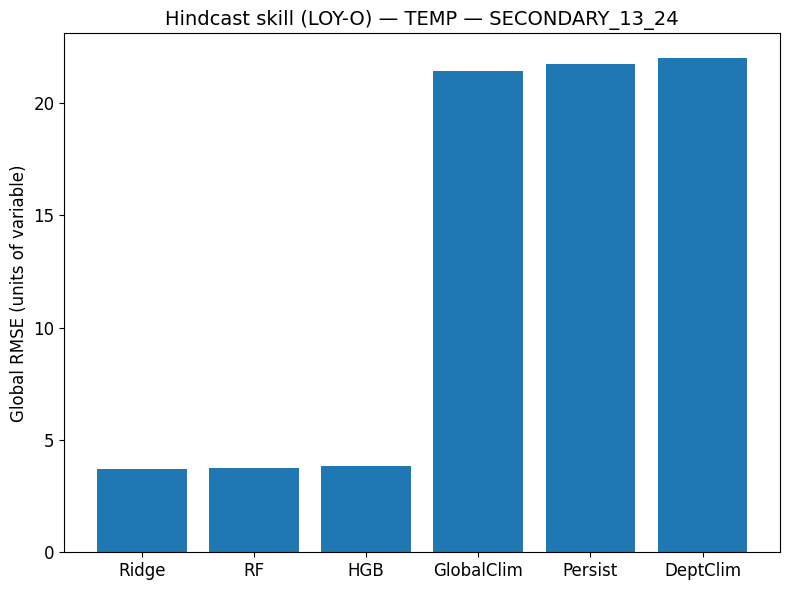

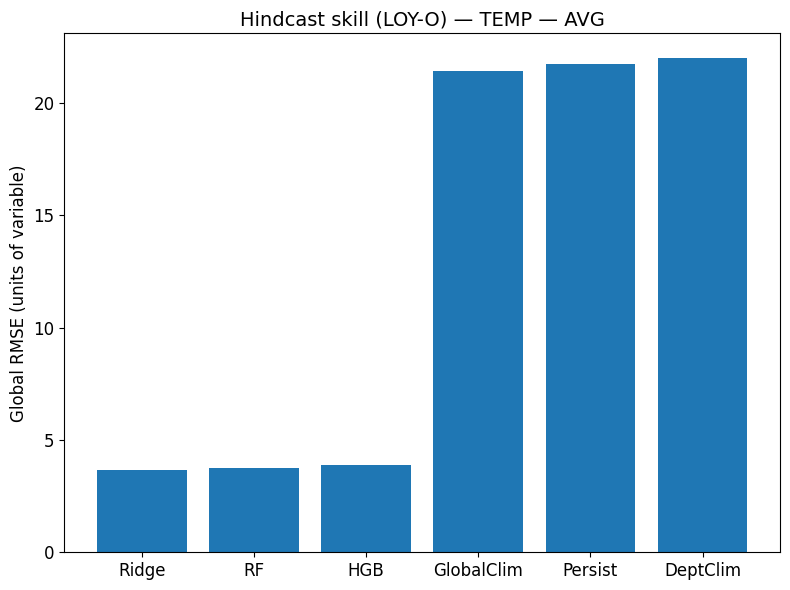

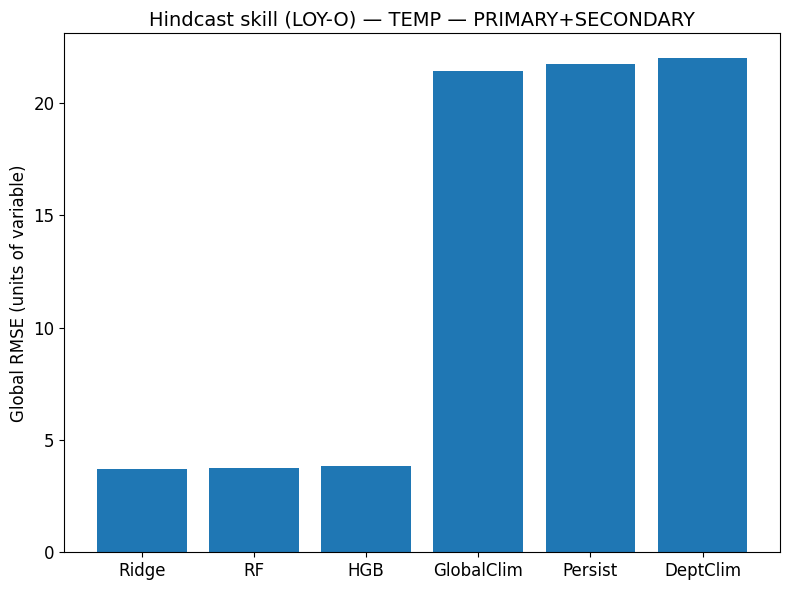

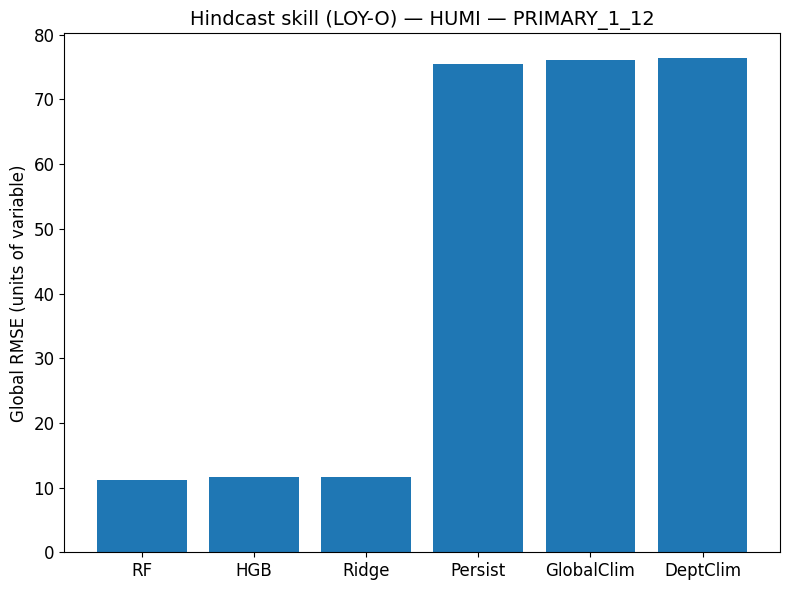

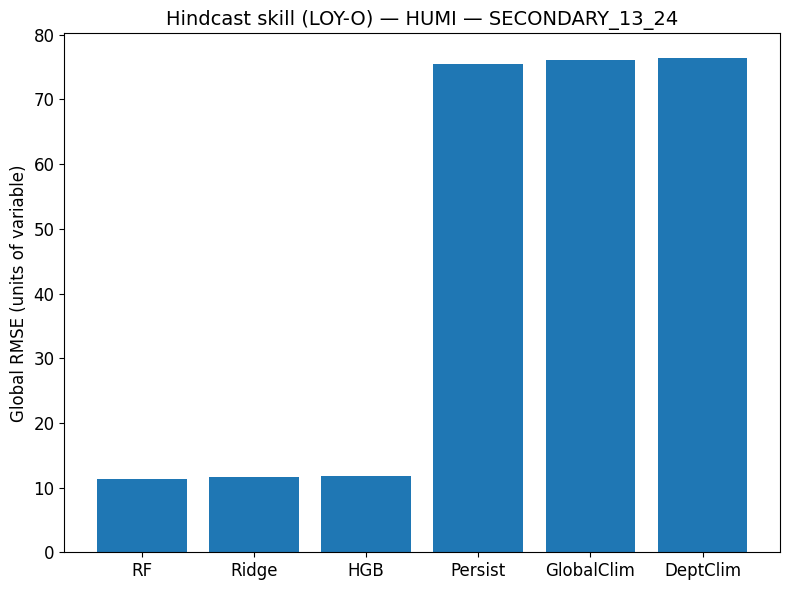

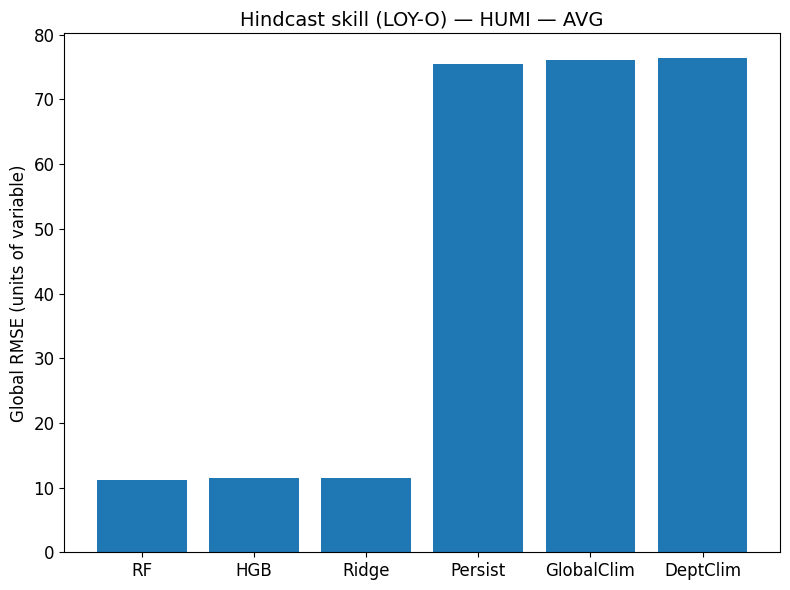

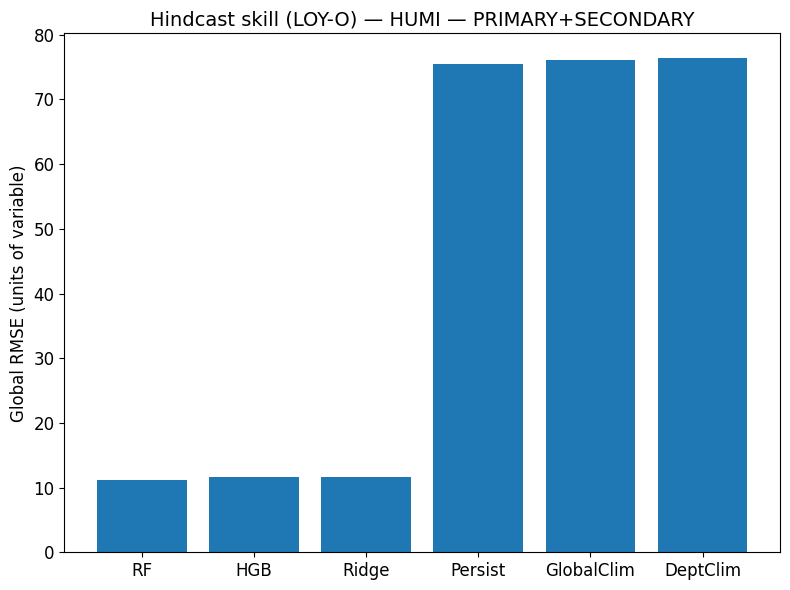

Listo. Outputs en: /Users/neno/Documents/Cabanuelas/Results/data/outputs_hindcast


In [9]:
# =========================
# RUN: compare feature sets for each target
# =========================
# Minimun Cleaning....
df = df.copy()
df[YEAR_COL]  = pd.to_numeric(df[YEAR_COL], errors="coerce")
df[MONTH_COL] = pd.to_numeric(df[MONTH_COL], errors="coerce")
df = df.dropna(subset=[YEAR_COL, MONTH_COL])
df[YEAR_COL]  = df[YEAR_COL].astype(int)
df[MONTH_COL] = df[MONTH_COL].astype(int)

# Run all (Activate detrend_target=True for a replic “detrended”)
DETREND_TARGET = True #False

all_pred = []
all_global = []
all_per_year = []

for tname, tcol in TARGETS.items():
    for fs_name, fs_cols in FEATURE_SETS.items():
        pred_all, global_all, per_year_all = run_multi_month(
            df_base=df,
            target_name=tname,
            target_col=tcol,
            feature_set_name=fs_name,
            feature_cols=fs_cols,
            detrend_target=DETREND_TARGET
        )

        all_pred.append(pred_all)
        all_global.append(global_all)
        all_per_year.append(per_year_all)

        # Export por target + feature set
        global_csv = OUTDIR / f"hindcast_summary_{tname}_{fs_name}.csv"
        peryr_csv  = OUTDIR / f"hindcast_per_year_{tname}_{fs_name}.csv"

        global_all.to_csv(global_csv, index=False)
        per_year_all.to_csv(peryr_csv, index=False)

        # Plot de RMSE promedio (como tus barras)
        plot_path = OUTDIR / f"rmse_bars_{tname}_{fs_name}.png"
        plot_rmse_bars(global_all, tname, fs_name, plot_path)

# Consolidate Export (útil para tablas finales)
pred_all_df   = pd.concat(all_pred, ignore_index=True)
global_all_df = pd.concat(all_global, ignore_index=True)
peryr_all_df  = pd.concat(all_per_year, ignore_index=True)

pred_all_df.to_csv(OUTDIR / "hindcast_predictions_ALL.csv", index=False)
global_all_df.to_csv(OUTDIR / "hindcast_summary_ALL.csv", index=False)
peryr_all_df.to_csv(OUTDIR / "hindcast_per_year_ALL.csv", index=False)

print("Listo. Outputs en:", OUTDIR.resolve())

## 1.2) Primary vs. Secondary “Comparative” Table (by RMSE)

This provides a table ready for discussion: by variable, month, and model, which version wins.

In [10]:
summary = pd.read_csv(OUTDIR / "hindcast_summary_ALL.csv")

# We are particularly interested in ML models vs baselines
keep_models = ["GlobalClim","DeptClim","Persist","Ridge","RF","HGB"]
summary = summary[summary["Model"].isin(keep_models)].copy()

# Pivot: RMSE by FeatureSet
pivot = summary.pivot_table(
    index=["Target","Month","Model"],
    columns="FeatureSet",
    values="RMSE",
    aggfunc="mean"
).reset_index()

# Who wins? (lower RMSE)
fs_cols = [c for c in pivot.columns if c not in ["Target","Month","Model"]]
pivot["Best_FeatureSet"] = pivot[fs_cols].idxmin(axis=1)

pivot.to_csv(OUTDIR / "compare_feature_sets_by_rmse.csv", index=False)
pivot.head(15)

FeatureSet,Target,Month,Model,AVG,PRIMARY+SECONDARY,PRIMARY_1_12,SECONDARY_13_24,Best_FeatureSet
0,HUMI,2,DeptClim,73.526482,73.526482,73.526482,73.526482,AVG
1,HUMI,2,GlobalClim,73.294417,73.294417,73.294417,73.294417,AVG
2,HUMI,2,HGB,8.125251,8.249998,8.239948,8.870275,AVG
3,HUMI,2,Persist,73.139255,73.139255,73.139255,73.139255,AVG
4,HUMI,2,RF,7.724940,7.809787,7.708164,7.845940,PRIMARY_1_12
5,HUMI,2,Ridge,8.051253,8.127083,8.432139,8.313173,AVG
6,HUMI,3,DeptClim,74.603024,74.603024,74.603024,74.603024,AVG
7,HUMI,3,GlobalClim,74.384989,74.384989,74.384989,74.384989,AVG
8,HUMI,3,HGB,10.180837,10.122768,10.393128,10.315810,PRIMARY+SECONDARY
9,HUMI,3,Persist,73.289644,73.289644,73.289644,73.289644,AVG


# Block 2 — Spearman + FDR correlations with 3 versions (prim/sec/avg)

In [11]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# -------------------------
# Config
# -------------------------
DEPT_COL  = "Departamento"
YEAR_COL  = "num__Year"
MONTH_COL = "num__Month"

TARGETS = {
    "RAIN": "num__Rain_month",
    "TEMP": "num__Temp_month",
    "HUMI": "num__Humi_month",
}

PREDICTORS = {
    "prim": {"RAIN": "num__Rain_day_prim", "TEMP": "num__Temp_day_prim", "HUMI": "num__Humi_day_prim"},
    "sec":  {"RAIN": "num__Rain_day_sec",  "TEMP": "num__Temp_day_sec",  "HUMI": "num__Humi_day_sec"},
    "avg":  {"RAIN": "num__Rain_day_avg",  "TEMP": "num__Temp_day_avg",  "HUMI": "num__Humi_day_avg"},
}

ALPHA_FDR = 0.05
MIN_N = 3  # minimum number of valid years per department-month to compute correlation

# -------------------------
# BH / FDR helper (con fallback)
# -------------------------
def fdr_bh(pvals, alpha=0.05):
    """
    Benjamini–Hochberg FDR correction.
    Returns q-values in the original order (NaNs preserved).
    """
    pvals = np.asarray(pvals, dtype=float)
    qvals = np.full_like(pvals, np.nan, dtype=float)

    mask = np.isfinite(pvals)
    pv = pvals[mask]
    m = pv.size
    if m == 0:
        return qvals

    order = np.argsort(pv)
    pv_sorted = pv[order]
    ranks = np.arange(1, m + 1)

    q_sorted = pv_sorted * m / ranks
    # enforce monotonicity
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.clip(q_sorted, 0, 1)

    q = np.empty_like(q_sorted)
    q[order] = q_sorted
    qvals[mask] = q
    return qvals

# -------------------------
# Minimal cleaning
# -------------------------
df = df.copy()

# Ensure numeric types in year/month
df[YEAR_COL]  = pd.to_numeric(df[YEAR_COL], errors="coerce")
df[MONTH_COL] = pd.to_numeric(df[MONTH_COL], errors="coerce")

# Normalize Department (for joins with shapes and consistency)
df[DEPT_COL] = (
    df[DEPT_COL].astype(str)
      .str.strip()
      .str.replace(r"\s+", " ", regex=True)
      .str.upper()
)

# Filter valid basic rows
df = df.dropna(subset=[DEPT_COL, YEAR_COL, MONTH_COL])
df[MONTH_COL] = df[MONTH_COL].astype(int)
df[YEAR_COL]  = df[YEAR_COL].astype(int)

months = sorted(df[MONTH_COL].unique().tolist())
depts  = sorted(df[DEPT_COL].unique().tolist())

# -------------------------
# Compute Spearman per (version, var, month, dept) pooling across years
# -------------------------
rows = []
for ver, pred_map in PREDICTORS.items():
    for var, ycol in TARGETS.items():
        xcol = pred_map[var]

        if xcol not in df.columns or ycol not in df.columns:
            raise ValueError(f"Missing columns for {ver}-{var}: x={xcol}, y={ycol}")

        for m in months:
            dff_m = df[df[MONTH_COL] == m]

            for d in depts:
                sub = dff_m[dff_m[DEPT_COL] == d][[xcol, ycol]].copy()

                x = sub[xcol]
                y = sub[ycol]
                valid = x.notna() & y.notna()
                n = int(valid.sum())

                if n >= MIN_N:
                    rho, p = spearmanr(x[valid].values, y[valid].values)
                else:
                    rho, p = np.nan, np.nan

                rows.append({
                    "Version": ver,           # prim / sec / avg
                    "Variable": var,          # RAIN / TEMP / HUMI
                    "Month": m,               # 1..12
                    "Departamento": d,
                    "n": n,
                    "rho": rho,
                    "p_raw": p,
                })

corr_df = pd.DataFrame(rows)

# -------------------------
# FDR correction across departments, per (version, variable, month)
# -------------------------
corr_df["q_FDR"] = np.nan
for (ver, var, m), idx in corr_df.groupby(["Version", "Variable", "Month"]).groups.items():
    pvals = corr_df.loc[idx, "p_raw"].values
    qvals = fdr_bh(pvals, alpha=ALPHA_FDR)
    corr_df.loc[idx, "q_FDR"] = qvals

corr_df["sig_FDR"] = corr_df["q_FDR"] < ALPHA_FDR

# Save master catalog
corr_df.to_csv("data/corr_outputs/spearman_master_v2.csv", index=False)
print("Saved:", "spearman_master_v2.csv", "| rows:", len(corr_df))

/var/folders/8n/h_rtmhz56bd84hgb5_cp68fc0000gn/T/ipykernel_1836/2820019803.py:106: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(x[valid].values, y[valid].values)
/var/folders/8n/h_rtmhz56bd84hgb5_cp68fc0000gn/T/ipykernel_1836/2820019803.py:106: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(x[valid].values, y[valid].values)
/var/folders/8n/h_rtmhz56bd84hgb5_cp68fc0000gn/T/ipykernel_1836/2820019803.py:106: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(x[valid].values, y[valid].values)
/var/folders/8n/h_rtmhz56bd84hgb5_cp68fc0000gn/T/ipykernel_1836/2820019803.py:106: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(x[valid].values, y[valid].values)
/var/folders/8n/h_rtmhz56bd84hgb5_cp68fc0000gn/T/ipykernel_1836/28200198

Saved: spearman_master_v2.csv | rows: 3564


In [12]:
depts

['AMAZONAS',
 'ANTIOQUIA',
 'ARAUCA',
 'ATLANTICO',
 'BOGOTA',
 'BOLIVAR',
 'BOYACA',
 'CALDAS',
 'CAQUETA',
 'CASANARE',
 'CAUCA',
 'CESAR',
 'CHOCO',
 'CORDOBA',
 'CUNDINAMARCA',
 'GUAINIA',
 'GUAVIARE',
 'HUILA',
 'LA GUAJIRA',
 'MAGDALENA',
 'META',
 'NARINO',
 'NORTE DE SANTANDER',
 'PUTUMAYO',
 'QUINDIO',
 'RISARALDA',
 'SAN ANDRES PROVIDENCIA',
 'SANTANDER',
 'SUCRE',
 'TOLIMA',
 'VALLE DEL CAUCA',
 'VAUPES',
 'VICHADA']

# Block 2.1 — Automatic summary tables (coverage and top 10)

In [13]:
import numpy as np
import pandas as pd

# -------------------------
# 1) Coverage (%) per month (by Version and Variable)
# -------------------------
coverage = (
    corr_df
    .groupby(["Version", "Variable", "Month"], as_index=False)
    .agg(
        n_depts=("sig_FDR", lambda s: int(np.isfinite(s).sum())),
        n_sig=("sig_FDR", lambda s: int(np.nansum(s.values.astype(float)))),
    )
)
coverage["pct_sig"] = 100.0 * coverage["n_sig"] / coverage["n_depts"].replace(0, np.nan)

# Pivot friendly: one table per version with TEMP/RAIN/HUMI columns
cov_pivots = {}
for ver in sorted(coverage["Version"].unique()):
    tmp = coverage[coverage["Version"] == ver].pivot(index="Month", columns="Variable", values="pct_sig")
    tmp = tmp.reindex(sorted(tmp.index))
    cov_pivots[ver] = tmp

# Export “larga” y “wide”
coverage.to_csv("monthly_percent_significant_v2.csv", index=False)
print("Saved:", "monthly_percent_significant_v2.csv")

for ver, tab in cov_pivots.items():
    out = f"monthly_percent_significant_{ver}_wide_v2.csv"
    tab.to_csv(out)
    print("Saved:", out)

# -------------------------
# 2) Top-10 FDR-significant by (Version, Variable) using |rho|
# -------------------------
top10 = (
    corr_df
    .dropna(subset=["rho", "q_FDR"])
    .query("sig_FDR == True")
    .assign(abs_rho=lambda d: d["rho"].abs())
    .sort_values(["Version", "Variable", "abs_rho"], ascending=[True, True, False])
    .groupby(["Version", "Variable"], as_index=False)
    .head(10)
    .drop(columns=["abs_rho"])
)

top10.to_csv("top10_FDRsignif_by_variable_v2.csv", index=False)
print("Saved:", "top10_FDRsignif_by_variable_v2.csv")

# (Optional) Top 10 WITHOUT FDR filtering
top10_unf = (
    corr_df
    .dropna(subset=["rho"])
    .assign(abs_rho=lambda d: d["rho"].abs())
    .sort_values(["Version", "Variable", "abs_rho"], ascending=[True, True, False])
    .groupby(["Version", "Variable"], as_index=False)
    .head(10)
    .drop(columns=["abs_rho"])
)
top10_unf.to_csv("data/corr_outputs/top10_by_variable_v2.csv", index=False)
print("Saved:", "top10_by_variable_v2.csv")

Saved: monthly_percent_significant_v2.csv
Saved: monthly_percent_significant_avg_wide_v2.csv
Saved: monthly_percent_significant_prim_wide_v2.csv
Saved: monthly_percent_significant_sec_wide_v2.csv
Saved: top10_FDRsignif_by_variable_v2.csv
Saved: top10_by_variable_v2.csv


# Bloque 2.2 — (Opcional) Mapas 12-paneles por versión usando tu función

In [14]:
import json, requests, geopandas as gpd
from pathlib import Path

# 1) GeoBoundaries API query for Colombia ADM1
api_url = "https://www.geoboundaries.org/api/current/gbOpen/COL/ADM1/"
r = requests.get(api_url, timeout=60)
r.raise_for_status()
meta = r.json()

# 2) Take the direct link to GeoJSON
gj_url = meta["gjDownloadURL"]
print("Descargando:", gj_url)

geojson_bytes = requests.get(gj_url, timeout=120).content
out_path = Path("col_departamentos.geojson")
out_path.write_bytes(geojson_bytes)
print("Guardado en:", out_path.resolve())

# 3) Load with GeoPandas and create a standardized 'Department' column
gdf = gpd.read_file(out_path)

# geoBoundaries usually includes 'shapeName' with the name of the ADM1
name_col = "shapeName" if "shapeName" in gdf.columns else None
if name_col is None:
    # Fallback: intenta otras columnas comunes
    for c in ["NAME_1", "name", "adm1_name", "shapeName_en"]:
        if c in gdf.columns:
            name_col = c
            break

if name_col is None:
    raise ValueError(f"No encontré columna con nombre del departamento. Columnas: {list(gdf.columns)}")

gdf["Departamento"] = gdf[name_col].str.upper()

# (Optional) Normalize some typical variants to match DF
reemplazos = {
    "BOGOTÁ, D.C.": "BOGOTA", 
    "BOYACÁ": "BOYACA", 
    "CAQUETÁ": "CAQUETA",
    "BOGOTA, D.C.": "BOGOTA", 
    "CHOCÓ": "CHOCO", 
    "SAN ANDRES": "SAN ANDRES PROVIDENCIA",
    "SAN ANDRÉS, PROVIDENCIA Y SANTA CATALINA": "SAN ANDRES PROVIDENCIA",
    "ARCHIPIÉLAGO DE SAN ANDRÉS, PROVIDENCIA Y SANTA CATALINA": "SAN ANDRES PROVIDENCIA",
    "VALLE DEL CAUCA": "VALLE DEL CAUCA", 
    "GUAINÍA": "GUAINIA",
    "NORTE DE SANTANDER": "NORTE DE SANTANDER", 
    "VAUPÉS": "VAUPES",
    "ATLÁNTICO": "ATLANTICO", 
    "CÓRDOBA": "CORDOBA",
    "GUAVIARE": "GUAVIARE",
    "BOGOTA CAPITAL DISTRICT": "BOGOTA", 
    "QUINDÍO": "QUINDIO",
    "BOLÍVAR": "BOLIVAR", 
    "NARIÑO": "NARINO",
}
gdf["Departamento"] = gdf["Departamento"].replace(reemplazos)

# 4) Save the GeoJSON file with the 'Department' column already included.
gdf.to_file("col_departamentos.geojson", driver="GeoJSON")
print("GeoJSON final con 'Departamento' listo para merge.")

# Prepare colormap
import matplotlib as mpl
cmap = mpl.cm.get_cmap('RdYlBu_r')
vmin, vmax = -1.0, 1.0

Descargando: https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/gbOpen/COL/ADM1/geoBoundaries-COL-ADM1.geojson
Guardado en: /Users/neno/Documents/Cabanuelas/Results/col_departamentos.geojson
GeoJSON final con 'Departamento' listo para merge.


/var/folders/8n/h_rtmhz56bd84hgb5_cp68fc0000gn/T/ipykernel_1836/3368801652.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdYlBu_r')


In [15]:
gdf["Departamento"]

0                     CALDAS
1                   AMAZONAS
2                       META
3               CUNDINAMARCA
4                     TOLIMA
5                  ANTIOQUIA
6                  ATLANTICO
7                    BOLIVAR
8                      CESAR
9                  MAGDALENA
10                     SUCRE
11                   CORDOBA
12                LA GUAJIRA
13                     CHOCO
14           VALLE DEL CAUCA
15        NORTE DE SANTANDER
16                   QUINDIO
17                   VICHADA
18                    VAUPES
19                 SANTANDER
20                 RISARALDA
21                  PUTUMAYO
22                    NARINO
23                  GUAVIARE
24                   GUAINIA
25                    BOGOTA
26                    ARAUCA
27                    BOYACA
28                  CASANARE
29                     CAUCA
30                   CAQUETA
31                     HUILA
32    SAN ANDRES PROVIDENCIA
Name: Departamento, dtype: object

In [16]:
#['AMAZONAS',
# 'ANTIOQUIA',
# 'ARAUCA',
# 'ATLANTICO',
# 'BOGOTA',
# 'BOLIVAR',
# 'BOYACA',
# 'CALDAS',
# 'CAQUETA',
# 'CASANARE',
# 'CAUCA',
# 'CESAR',
# 'CHOCO',
# 'CORDOBA',
# 'CUNDINAMARCA',
# 'GUAINIA',
# 'GUAVIARE',
# 'HUILA',
# 'LA GUAJIRA',
# 'MAGDALENA',
# 'META',
# 'NARINO',
# 'NORTE DE SANTANDER',
# 'PUTUMAYO',
# 'QUINDIO',
# 'RISARALDA',
# 'SAN ANDRES PROVIDENCIA',
# 'SANTANDER',
# 'SUCRE',
# 'TOLIMA',
# 'VALLE DEL CAUCA',
# 'VAUPES',
# 'VICHADA']

/var/folders/8n/h_rtmhz56bd84hgb5_cp68fc0000gn/T/ipykernel_1836/4243782352.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('RdYlBu_r')


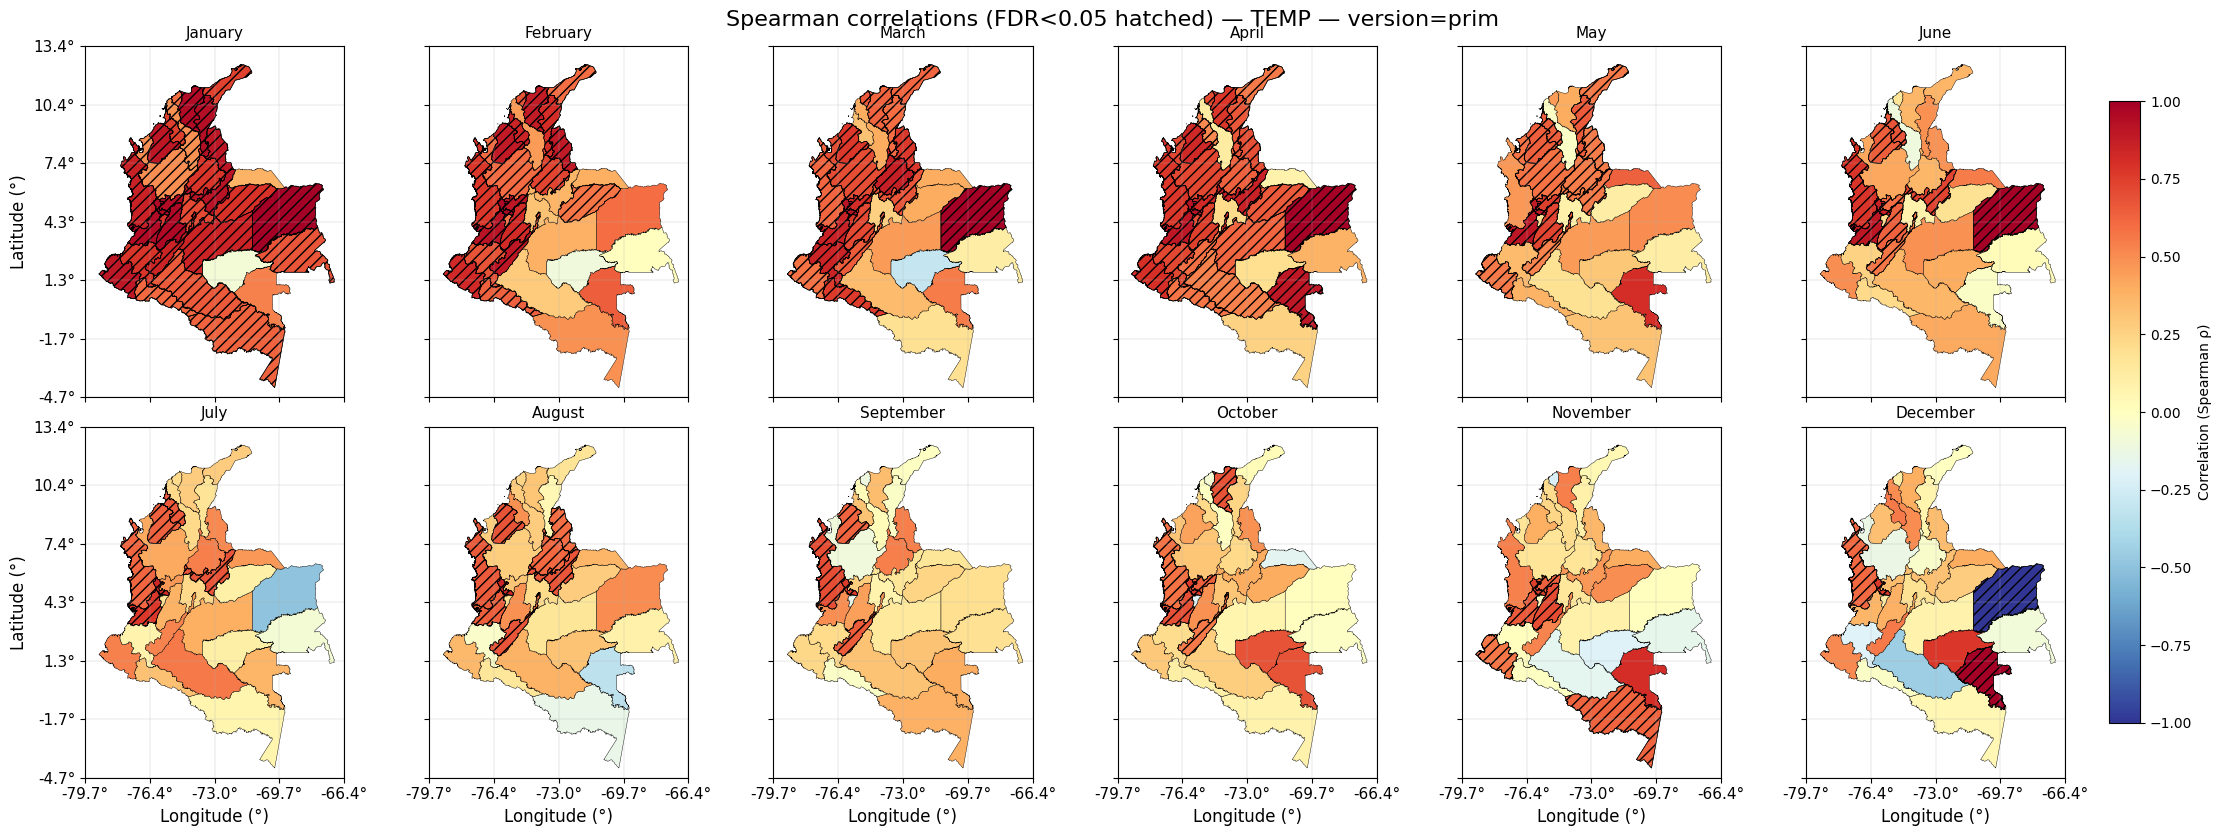

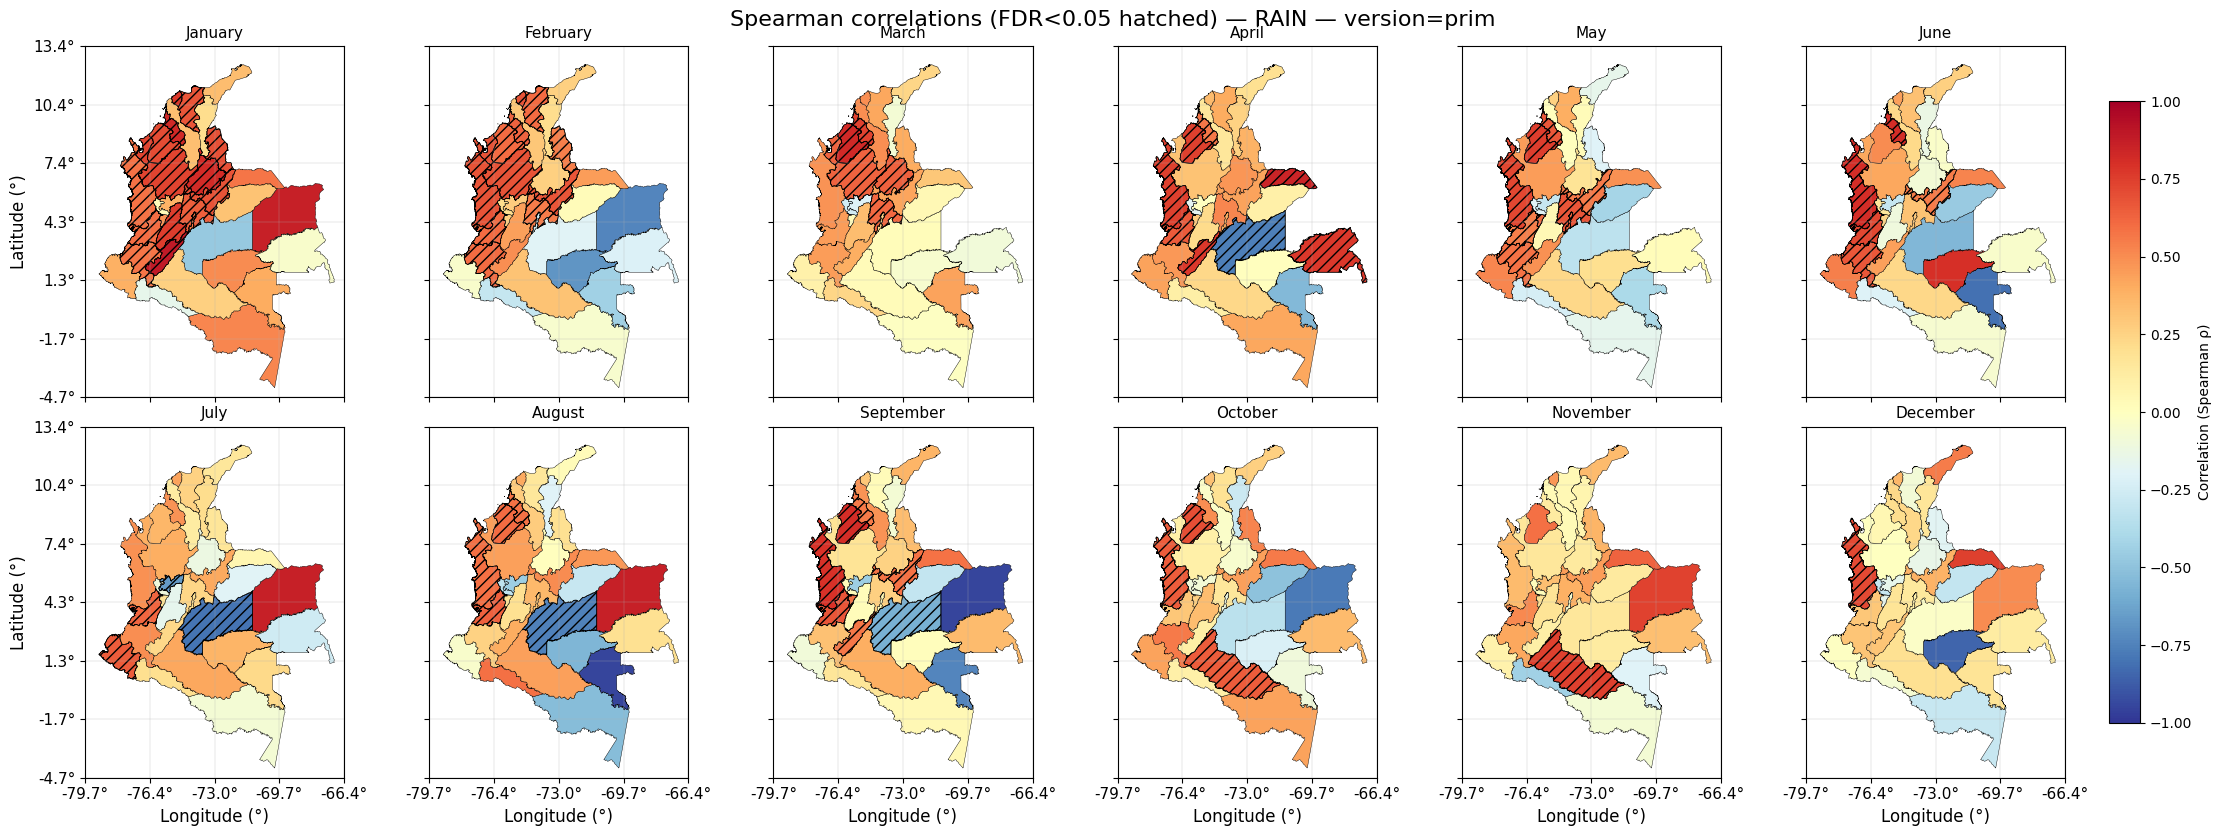

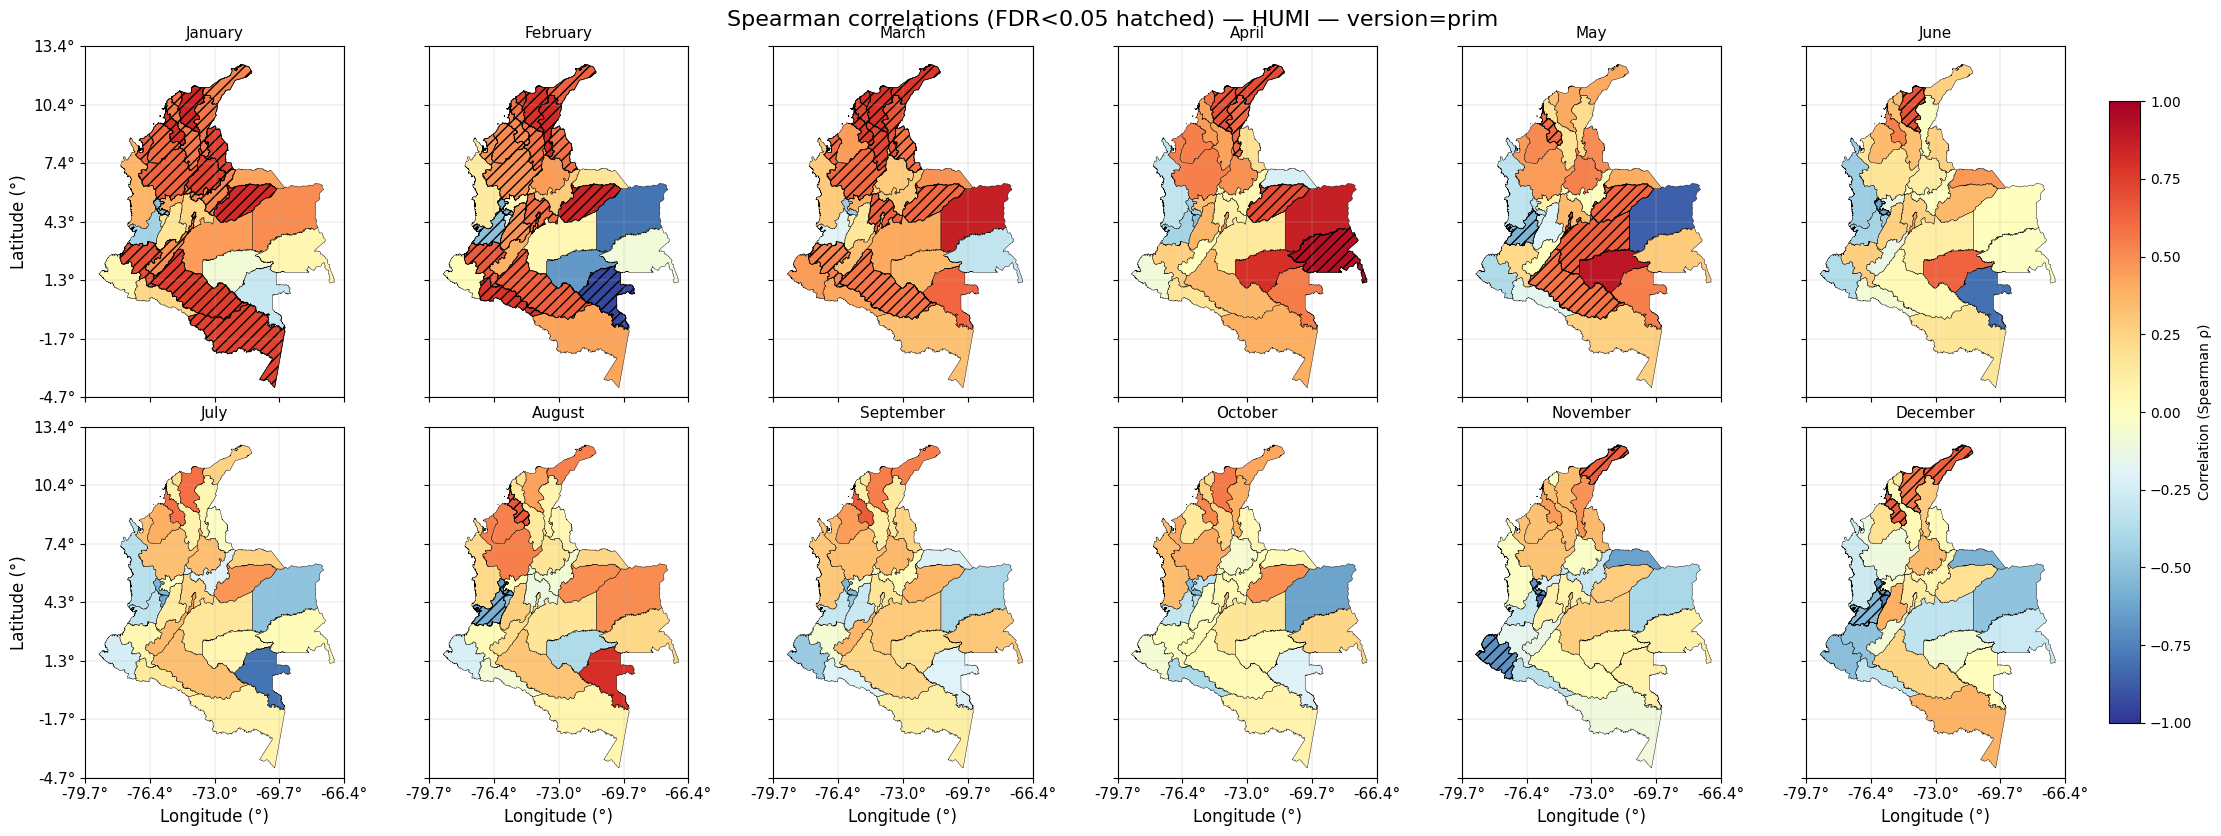

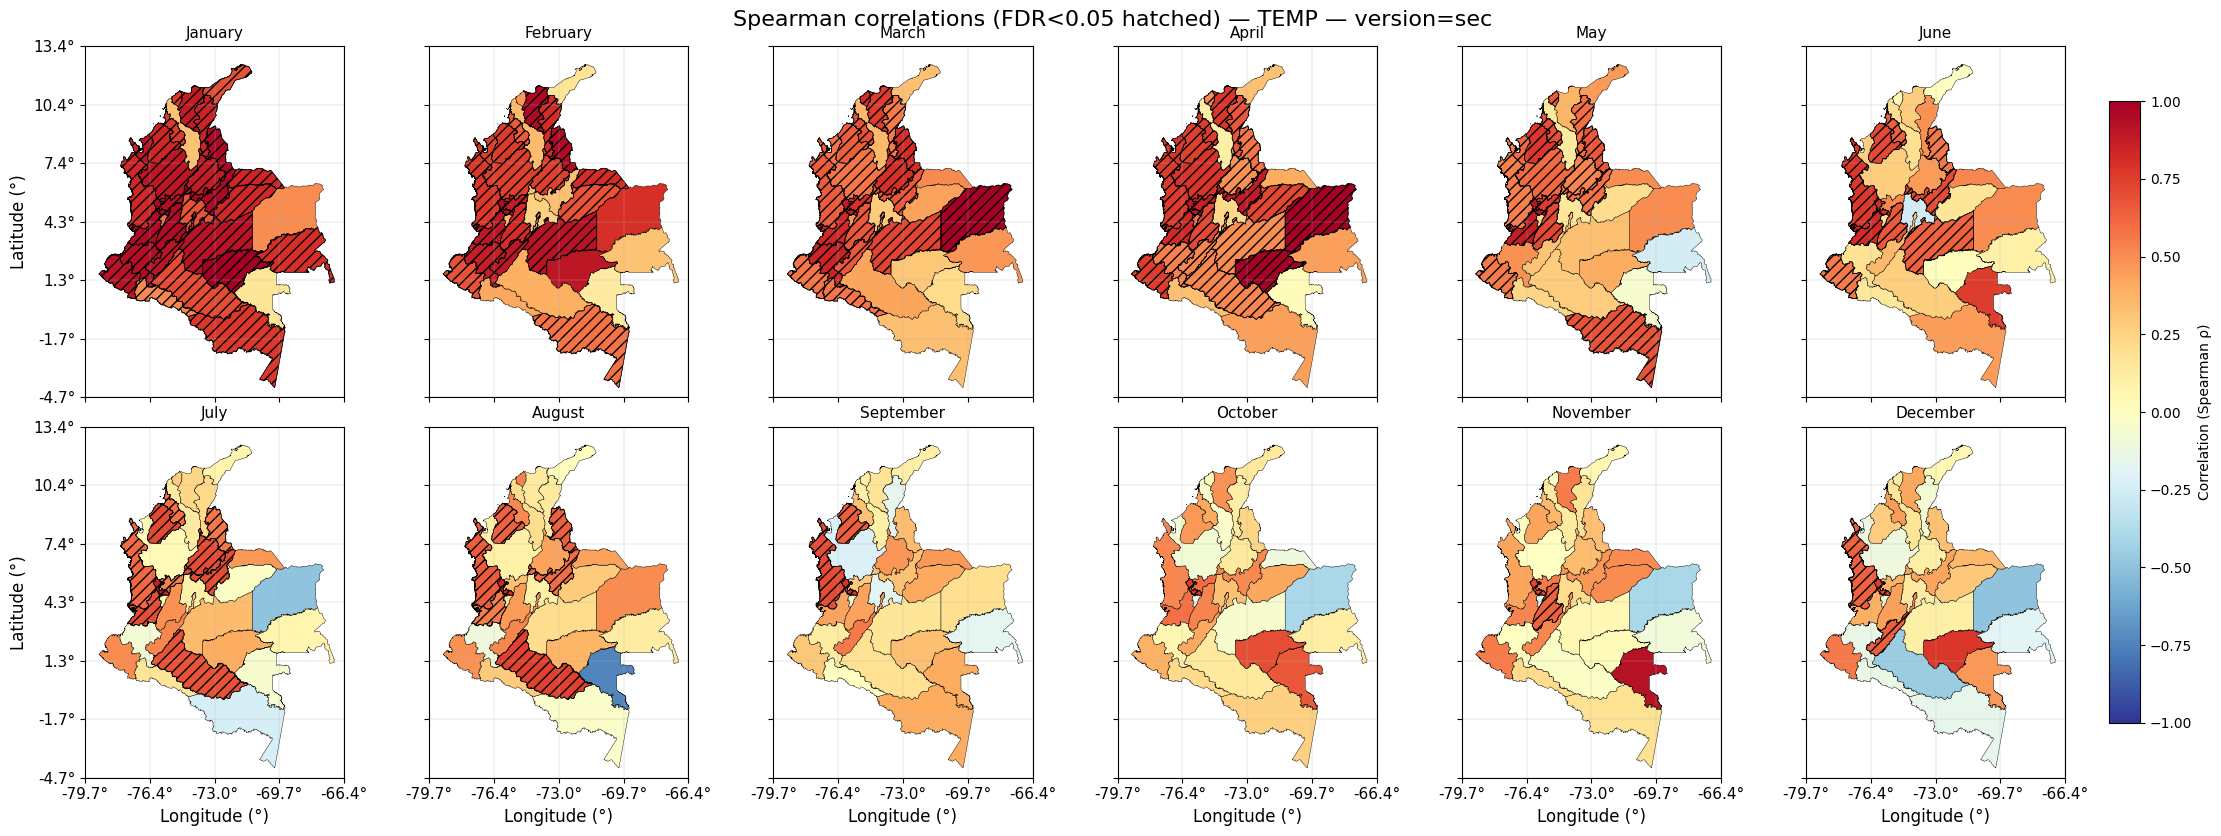

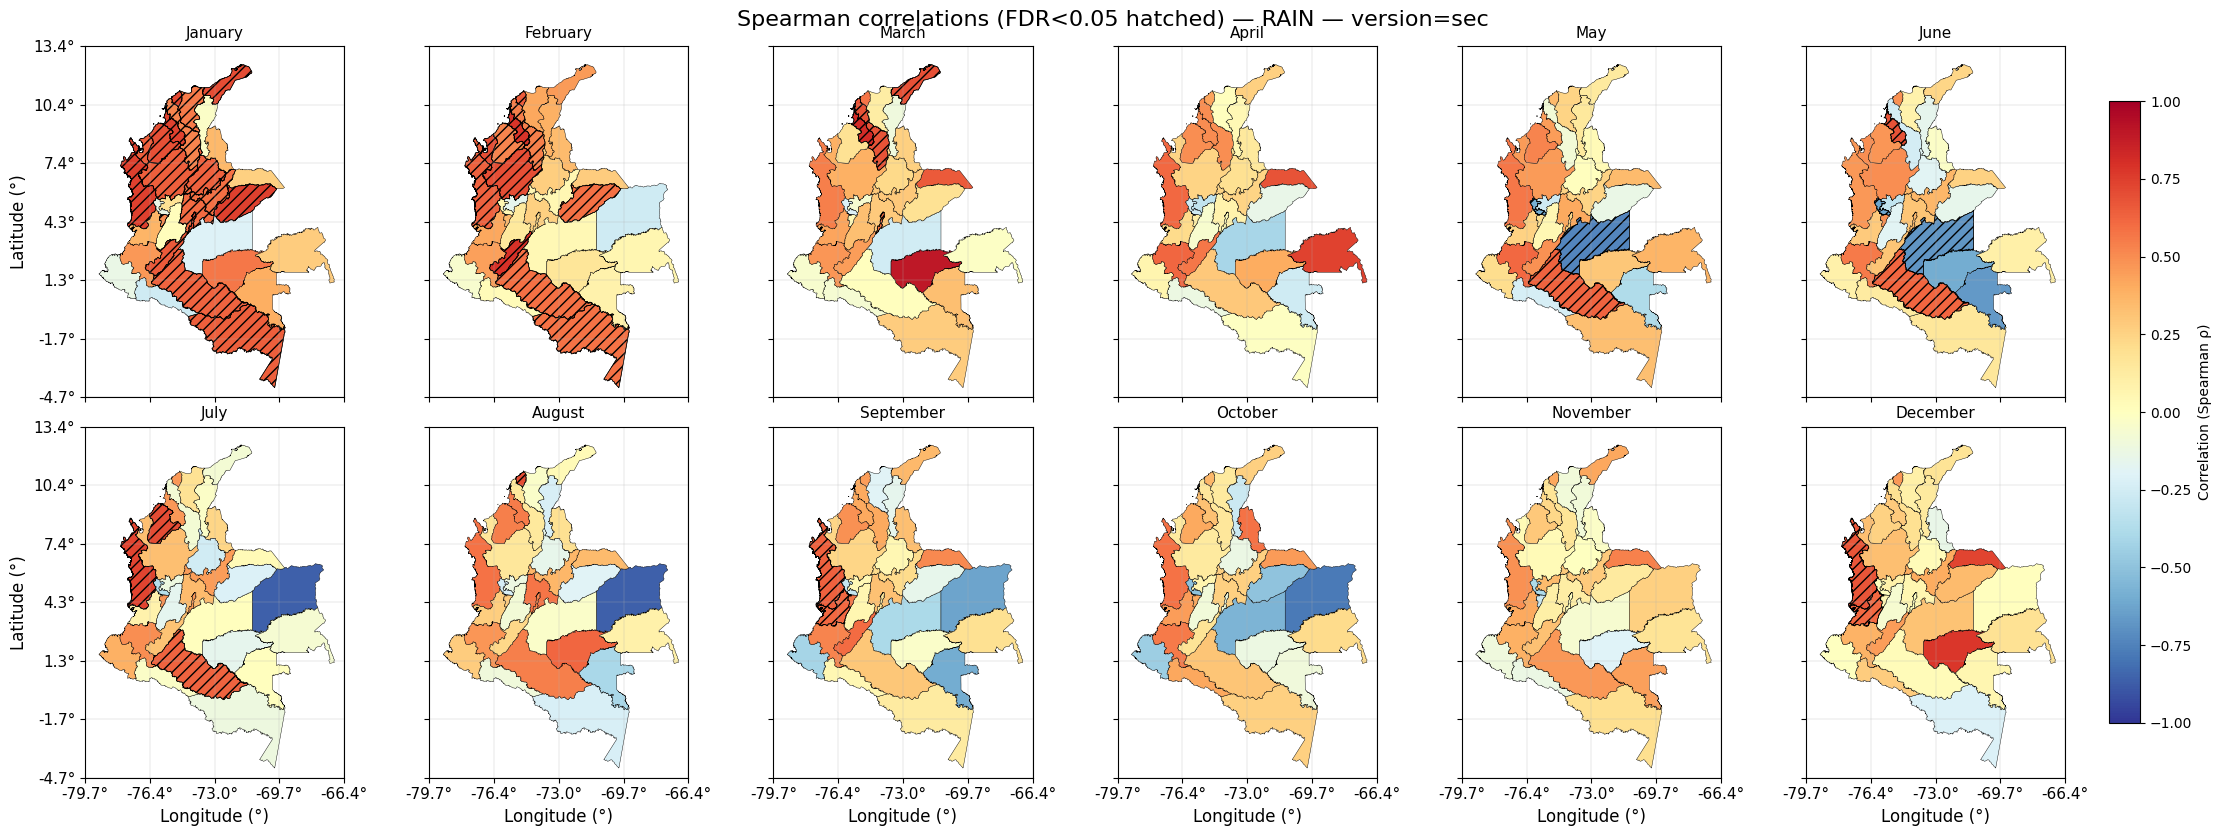

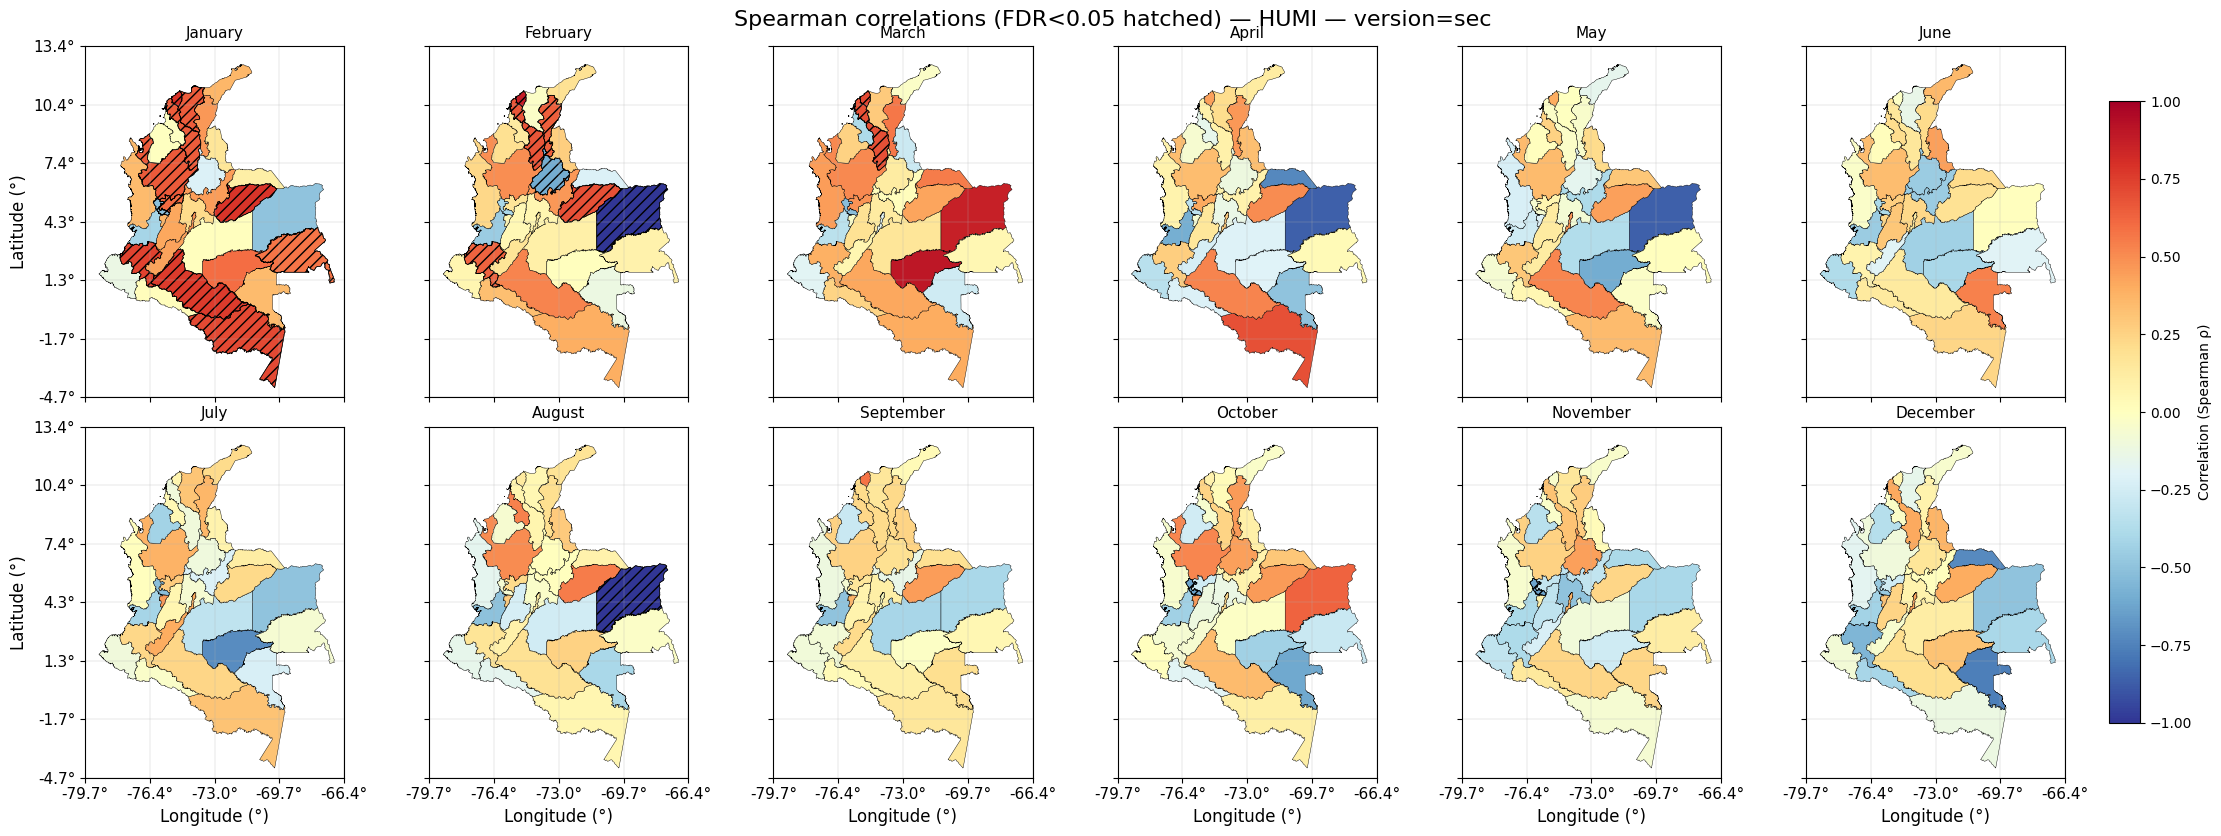

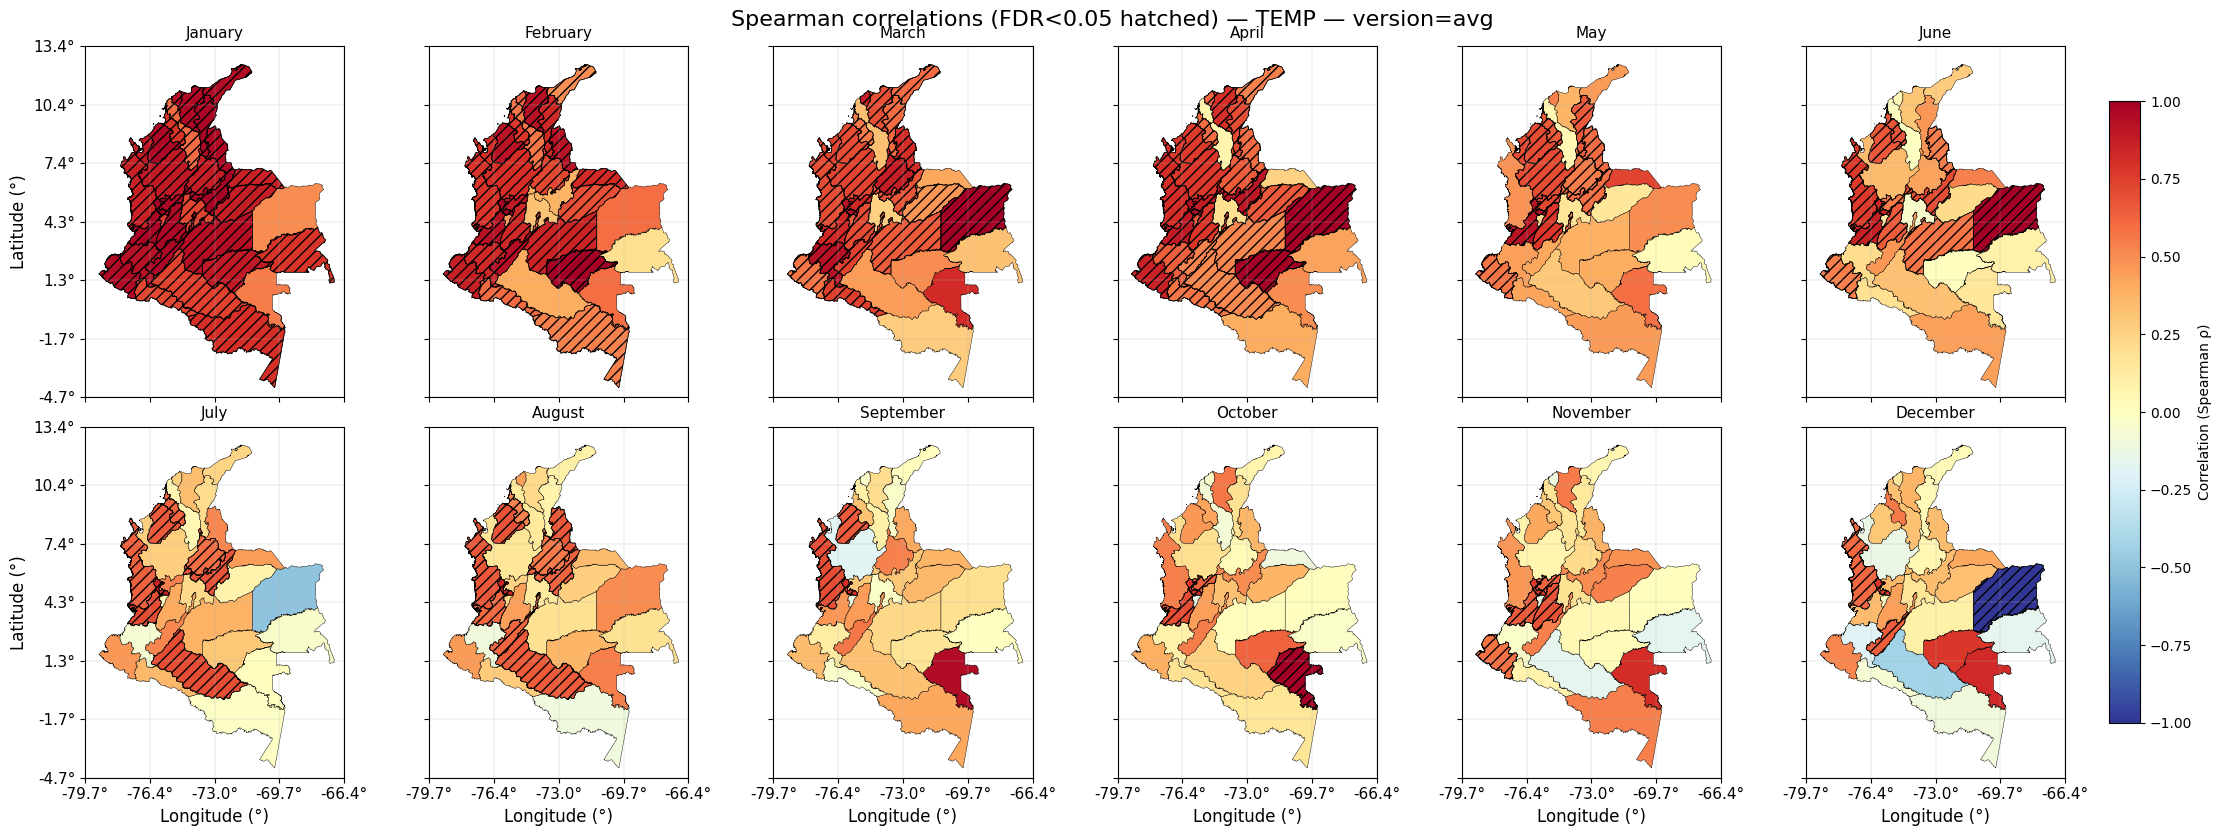

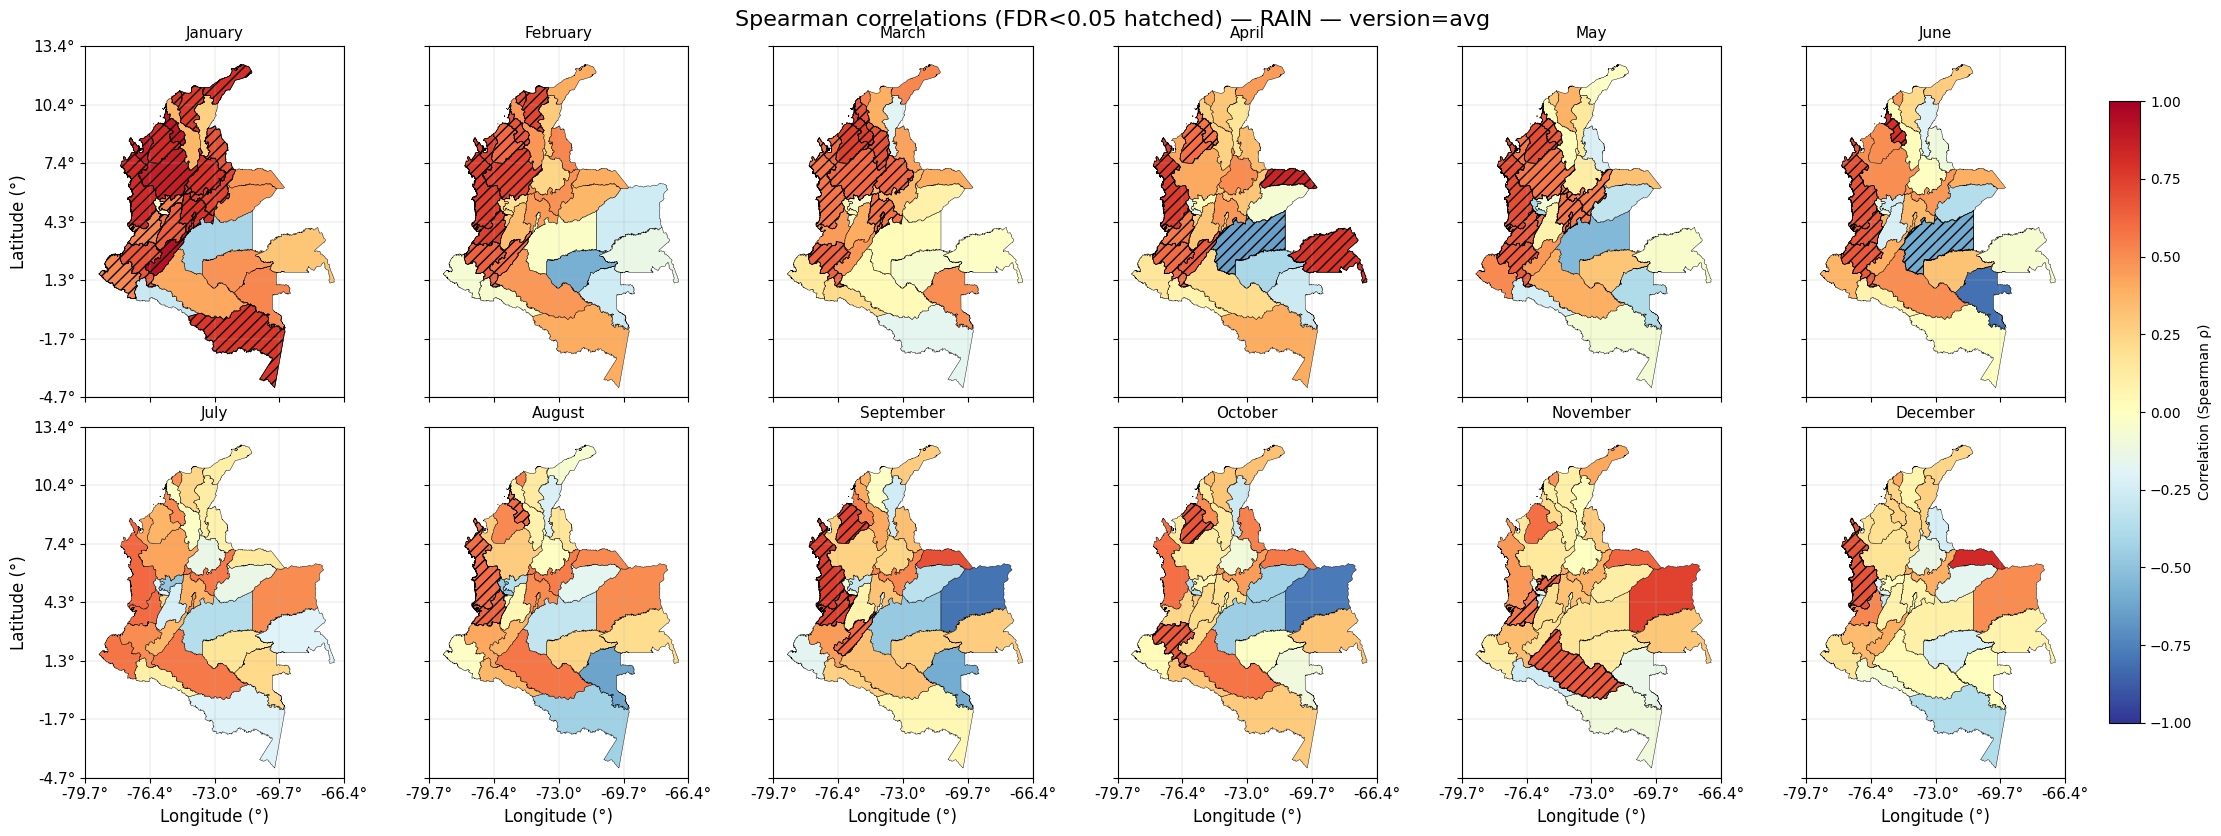

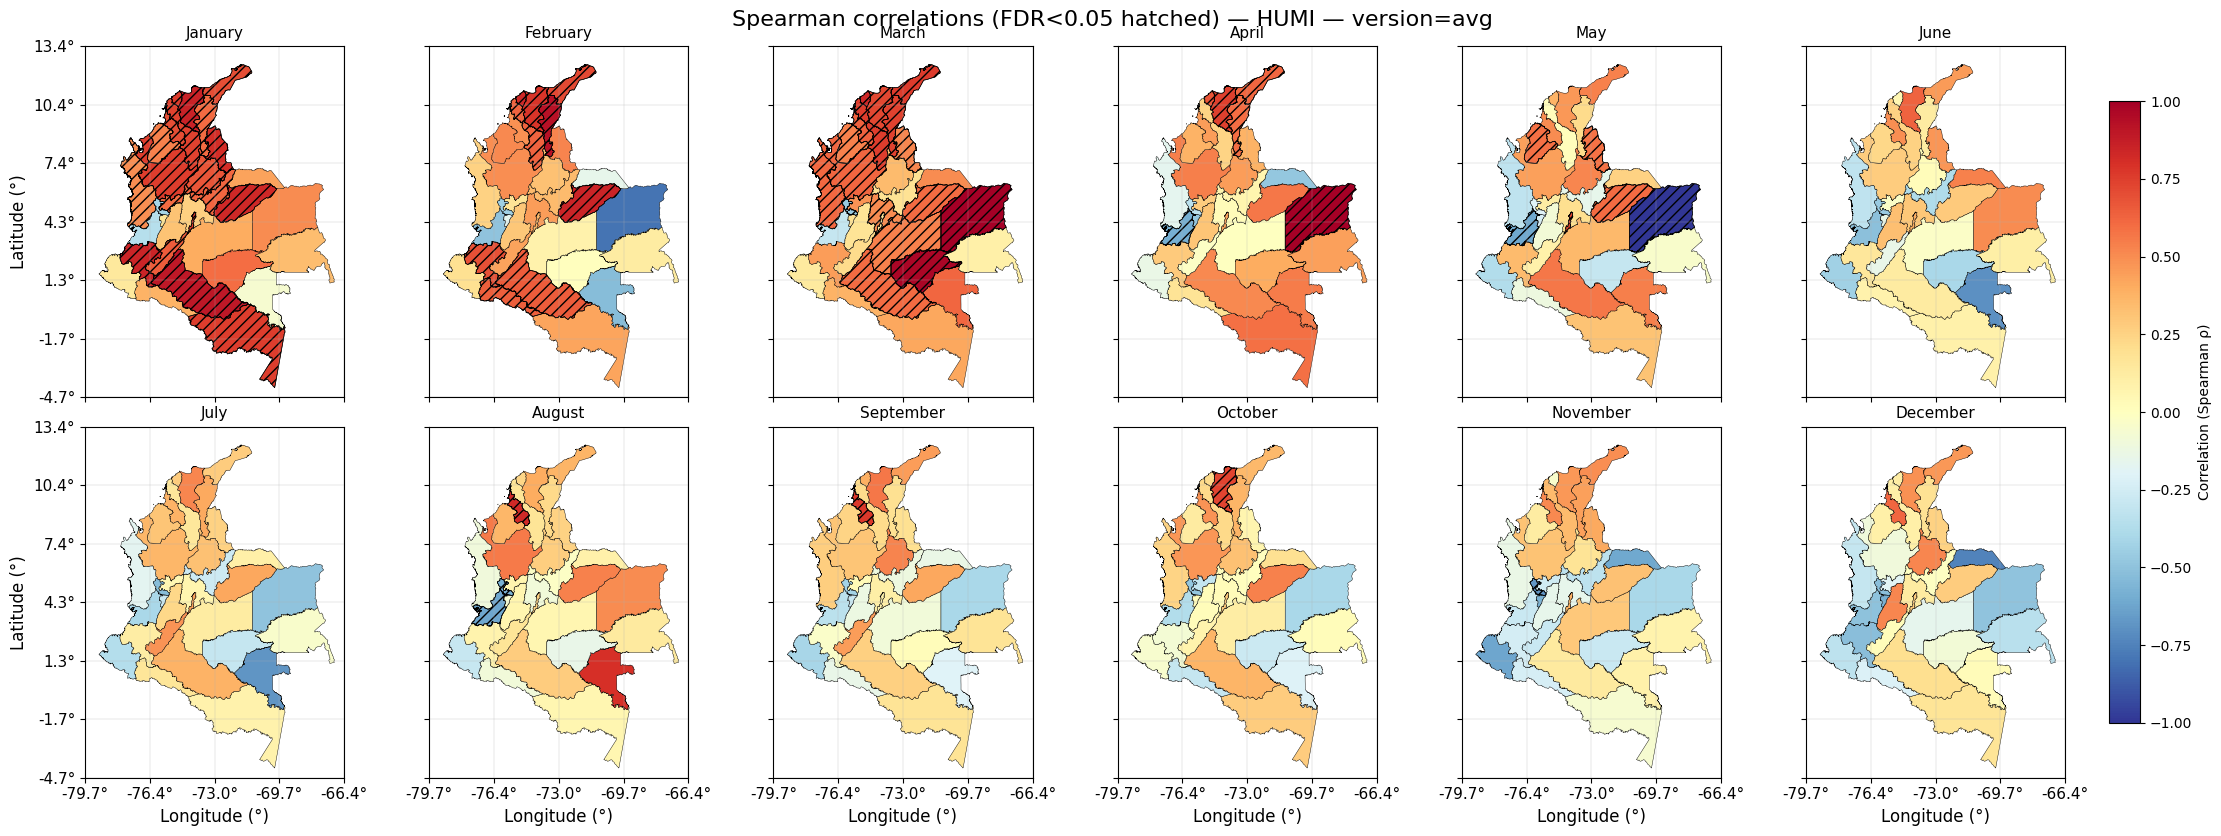

In [22]:
# =========================
# 12-PANEL MAPS PER VARIABLE AND VERSION (hatching = FDR < 0.05) with AXES
# =========================
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import FuncFormatter

GEO_PATH = "col_departamentos.geojson"  
MAP_OUTDIR = "data/corr_outputs/maps/"
#MAP_OUTDIR.mkdir(parents=True, exist_ok=True)

# ---------- cargar shapes ----------
gdf = gpd.read_file(GEO_PATH)

cand_cols = ['Departamento','DEPARTAMEN','NOMBRE_DPT','NOMBRE_DEP','DPTO','NOMBRE']
for c in cand_cols:
    if c in gdf.columns:
        gdf = gdf.rename(columns={c: 'Departamento'})
        break

gdf['Departamento'] = (
    gdf['Departamento'].astype(str)
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
)

# Colormap
cmap = mpl.cm.get_cmap('RdYlBu_r')
vmin, vmax = -1.0, 1.0

def _deg_fmt(x, pos):
    return f"{x:.1f}°"

month_names = {1:'January',2:'February',3:'March',4:'April',5:'May',6:'June',
               7:'July',8:'August',9:'September',10:'October',11:'November',12:'December'}

# ticks comunes
minx, miny, maxx, maxy = gdf.total_bounds
xticks = np.linspace(minx+2, maxx+0.5, 5)
yticks = np.linspace(miny-0.5, maxy, 7)

# meses presentes en tu corr_df (idealmente 1..12)
MONTHS = sorted(corr_df["Month"].unique().tolist())

def plot_12_month_panels(var, version="avg", value_col="rho", sig_flag="sig_FDR"):
    """
    var in {'TEMP','RAIN','HUMI'}
    version in {'prim','sec','avg'}
    value_col: 'rho' por defecto
    sig_flag: 'sig_FDR' (o 'sig_raw', etc.)
    """
    dfv = corr_df[(corr_df["Variable"] == var) & (corr_df["Version"] == version)].copy()

    ncols, nrows = 6, 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(22, 8), constrained_layout=True)
    axes = axes.ravel()

    # >>> KEY: Press space while holding constrained_layout <<<
    if hasattr(fig, "set_constrained_layout_pads"):
        fig.set_constrained_layout_pads(
            w_pad=0.004, h_pad=-0.04,
            wspace=0.010, hspace=-0.010
        )

    for idx, m in enumerate(MONTHS):
        ax = axes[idx]
        sub = dfv[dfv["Month"] == m][["Departamento", value_col, sig_flag]].copy()
        gplot = gdf.merge(sub, on="Departamento", how="left")

        gplot.plot(column=value_col, cmap=cmap, vmin=vmin, vmax=vmax,
                   linewidth=0.3, edgecolor="black", ax=ax, legend=False)

        sig_layer = gplot[gplot[sig_flag] == True]
        if not sig_layer.empty:
            sig_layer.plot(ax=ax, facecolor="none", edgecolor="black",
                           linewidth=0.5, hatch="///")

        ax.set_title(month_names.get(m, str(m)), fontsize=11)

        ax.set_aspect("equal")
        ax.set_xlim(minx+2, maxx+0.5); ax.set_ylim(miny-0.5, maxy)
        ax.set_xticks(xticks); ax.set_yticks(yticks)
        ax.xaxis.set_major_formatter(FuncFormatter(_deg_fmt))
        ax.yaxis.set_major_formatter(FuncFormatter(_deg_fmt))
        ax.tick_params(labelsize=11)
        ax.grid(True, linewidth=0.3, alpha=0.7)

        if idx % ncols != 0:
            ax.set_ylabel("")
            ax.set_yticklabels([])
        else:
            ax.set_ylabel("Latitude (°)", fontsize=12)

        if idx < (nrows - 1) * ncols:
            ax.set_xlabel("")
            ax.set_xticklabels([])
        else:
            ax.set_xlabel("Longitude (°)", fontsize=12)

    # colorbar común (más pegada y delgada)
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
    sm._A = []
    cbar = fig.colorbar(sm, ax=axes.tolist(), shrink=0.85, pad=0.01, fraction=0.03)
    cbar.set_label("Correlation (Spearman ρ)")

    fig.suptitle(
        f"Spearman correlations (FDR<0.05 hatched) — {var} — version={version}",
        y=1.02, fontsize=16
    )

    outpath = f"data/corr_outputs/maps/corr_panels_{var}_spearman_FDR_{version}_axes.png"
    fig.savefig(outpath, dpi=200, bbox_inches="tight")
    plt.show()
    return outpath


# === genera los 9 paneles (3 vars × 3 versiones) ===
for ver in ["prim", "sec", "avg"]:
    plot_12_month_panels("TEMP", version=ver)
    plot_12_month_panels("RAIN", version=ver)
    plot_12_month_panels("HUMI", version=ver)

# Tables

## Corrrelations

In [ ]:
# =========================
# Helpers de formato LaTeX
# =========================
MONTH_NAME = {
    1:"January",2:"February",3:"March",4:"April",5:"May",6:"June",
    7:"July",8:"August",9:"September",10:"October",11:"November",12:"December"
}

def fmt_month(m):
    try:
        m = int(m)
        return MONTH_NAME.get(m, str(m))
    except:
        return str(m)

def fmt_float(x, nd=3):
    if pd.isna(x): 
        return "NaN"
    return f"{float(x):.{nd}f}"

def fmt_percent(x, nd=1):
    if pd.isna(x):
        return "NaN"
    return f"{float(x):.{nd}f}"

def fmt_thousands_latex(x, nd=2):
    """12,920.52 -> 12\\,920.52"""
    if pd.isna(x):
        return "NaN"
    s = f"{float(x):,.{nd}f}"
    return s.replace(",", r"\,")

def fmt_sci_latex(x, sig=2):
    """2.0e-13 -> 2.0\\times 10^{-13}"""
    if pd.isna(x):
        return "NaN"
    x = float(x)
    if x == 0:
        return "0"
    exp = int(np.floor(np.log10(abs(x))))
    mant = x / (10**exp)
    return rf"{mant:.{sig}f}\times 10^{{{exp}}}"

def df_to_tabular_with_rules(df, colspec, header_bold=True):
    """
    Devuelve SOLO el tabular (con | y tu \\thickhline).
    Asume que df ya trae strings formateados.
    """
    cols = list(df.columns)
    lines = []
    lines.append(rf"\begin{{tabular}}{{{colspec}}}")
    lines.append(r"\hline")
    if header_bold:
        header = " & ".join([rf"\textbf{{{c}}}" for c in cols]) + r" \\"
    else:
        header = " & ".join(cols) + r" \\"
    lines.append(header)
    lines.append(r"\thickhline")
    for _, row in df.iterrows():
        lines.append(" & ".join([str(row[c]) for c in cols]) + r" \\ \hline")
    lines.append(r"\end{tabular}")
    return "\n".join(lines)

def wrap_table(tabular, caption, label, centering=True, adjustwidth=False, left="-2.25in", right="0in"):
    """
    Envuelve en \\begin{table} ... \\end{table}. Si adjustwidth=True,
    mete el tabular dentro de adjustwidth.
    """
    parts = [r"\begin{table}[htb]"]
    if adjustwidth:
        parts.append(rf"\begin{{adjustwidth}}{{{left}}}{{{right}}}")
    if centering:
        parts.append(r"\centering")
    parts.append(rf"\caption{{{caption}}}")
    parts.append(rf"\label{{{label}}}")
    parts.append(tabular)
    if adjustwidth:
        parts.append(r"\end{adjustwidth}")
    parts.append(r"\end{table}")
    return "\n".join(parts)

# ==========================================================
# (A) CORRELATIONS: percent_sig_by_month + top10 per variable
# ==========================================================
def make_percent_sig_by_month_table(corr_df, version="avg", q_col="q_fdr", sig_col="sig_FDR"):
    """
    corr_df esperado: ['Departamento','Month','Variable','Version', q_col, sig_col, ...]
    Devuelve LaTeX table completa (table+tabular).
    """
    dfv = corr_df[corr_df["Version"] == version].copy()

    # Percentage of significant departments per month and variable
    out = []
    for m in sorted(dfv["Month"].unique()):
        row = {"Month": fmt_month(m)}
        for var in ["TEMP","RAIN","HUMI"]:
            d = dfv[(dfv["Month"]==m) & (dfv["Variable"]==var)]
            # cobertura = #deptos con sig / #deptos con dato
            denom = d["Departamento"].nunique()
            num = d.loc[d[sig_col]==True, "Departamento"].nunique()
            pct = 100.0 * num/denom if denom>0 else np.nan
            row[var] = fmt_percent(pct, nd=1)
        out.append(row)

    tab = pd.DataFrame(out)[["Month","TEMP","RAIN","HUMI"]].rename(columns={
        "Month":"Month", "TEMP":"TEMP (\\%)", "RAIN":"RAIN (\\%)", "HUMI":"HUMI (\\%)"
    })

    tabular = df_to_tabular_with_rules(tab, colspec="|l+ccc|")
    caption = (rf"{{\bf Coverage of FDR-significant correlations ($q<0.05$) by month "
               rf"(version={version}).}} For each month $m$, the table reports the percentage of departments "
               rf"with significant Spearman correlation between the mapped Cabañuelas day(s) and the same-year monthly mean "
               rf"for TEMP, RAIN, and HUMI.")
    label = f"tab:percent_sig_by_month_{version}"
    return wrap_table(tabular, caption, label)

def make_top10_fdr_table(corr_df, var="RAIN", version="avg", rho_col="rho", q_col="q_FDR", sig_col="sig_FDR", n=10):
    """
    Tabla Top-n por |rho| entre los significativos FDR.
    """
    dfv = corr_df[(corr_df["Variable"]==var) & (corr_df["Version"]==version)].copy()
    dfv = dfv[dfv[sig_col]==True].copy()
    dfv["absrho"] = dfv[rho_col].abs()
    dfv = dfv.sort_values("absrho", ascending=False).head(n)

    tab = pd.DataFrame({
        "Department": dfv["Departamento"].astype(str).values,
        "Month": [fmt_month(m) for m in dfv["Month"].values],
        r"$\rho$ (Spearman)": [fmt_float(x, nd=3) for x in dfv[rho_col].values],
        r"$q$ (FDR)": [fmt_sci_latex(x, sig=1) for x in dfv[q_col].values],
    })

    tabular = df_to_tabular_with_rules(tab, colspec="|l+ccc|")
    caption = (rf"{{\bf Top FDR-significant department--month pairs for {var} "
               rf"(version={version}).}} Ten largest $|\rho|$ among {var} entries with $q<0.05$.")
    label = f"tab:top10_{var.lower()}_fdr_{version}"
    return wrap_table(tabular, caption, label)


In [ ]:
print(make_percent_sig_by_month_table(corr_df, version="prim"))
print(make_percent_sig_by_month_table(corr_df, version="sec"))
print(make_percent_sig_by_month_table(corr_df, version="avg"))
#
print(make_top10_fdr_table(corr_df, var="RAIN", version="prim"))
print(make_top10_fdr_table(corr_df, var="RAIN", version="sec"))
print(make_top10_fdr_table(corr_df, var="RAIN", version="avg"))

## Hindcast

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

# ========= CONFIG =========
HINDCAST_DIR = Path("data/outputs_hindcast")   
OUT_TEX_HIND = Path("data/outputs_hindcast/tables_hindcast_ALL.tex") 

MONTH_NAMES = {
    1:'January',2:'February',3:'March',4:'April',5:'May',6:'June',
    7:'July',8:'August',9:'September',10:'October',11:'November',12:'December'
}

def slugify(s: str) -> str:
    s = str(s).strip().lower().replace("+","_plus_").replace("-","_").replace(" ","_")
    s = "".join(ch for ch in s if ch.isalnum() or ch == "_")
    s = "_".join([p for p in s.split("_") if p])
    return s

def _clean_model_name(s):
    s0 = str(s).strip().lower()
    if s0 in ["globalclim","global_clim","climatology","clim","global"]:
        return "GlobalClim"
    if s0 in ["deptclim","dept_clim","dept"]:
        return "DeptClim"
    if s0 in ["persist","persistence"]:
        return "Persist"
    if "ridge" in s0:
        return "Ridge"
    if ("random" in s0 and "forest" in s0) or s0 in ["rf","randomforest","randomforestregressor"]:
        return "Random Forest"
    if ("hist" in s0 and "gradient" in s0) or s0 in ["hgb","histgradientboosting","histgradientboostingregressor"]:
        return "HistGradientBoosting"
    return str(s).strip()

def df_to_latex_pipe(df, caption, label, colspec="|l+ccc|"):
    cols = list(df.columns)
    lines = []
    lines += [r"\begin{table}[htb]",
              r"\centering",
              rf"\caption{{{caption}}}",
              rf"\label{{{label}}}",
              rf"\begin{{tabular}}{{{colspec}}}",
              r"\hline",
              " & ".join([rf"\textbf{{{c}}}" for c in cols]) + r" \\",
              r"\thickhline"]
    for _, row in df.iterrows():
        lines.append(" & ".join(map(str, row.values)) + r" \\ \hline")
    lines += [r"\end{tabular}", r"\end{table}"]
    return "\n".join(lines)

def latex_skill_table_from_summary(path, baseline="GlobalClim", months=range(2,13)):
    df = pd.read_csv(path).copy()
    df["Month"] = pd.to_numeric(df["Month"], errors="coerce").astype("Int64")
    df["Model_clean"] = df["Model"].apply(_clean_model_name)

    df = df[df["Month"].isin(list(months))].copy()

    base_df = df[df["Model_clean"] == baseline][["Month", "RMSE"]].dropna()
    if base_df.empty:
        raise ValueError(f"No baseline '{baseline}' en {path.name}. Model_clean: {sorted(df['Model_clean'].unique())}")

    base = base_df.set_index("Month")["RMSE"].to_dict()

    def _skill(row):
        b = base.get(int(row["Month"]), np.nan)
        if pd.isna(b) or b == 0:
            return np.nan
        return 1.0 - (row["RMSE"] / b)

    df["Skill"] = df.apply(_skill, axis=1)

    wanted = ["Ridge", "Random Forest", "HistGradientBoosting"]
    piv = df[df["Model_clean"].isin(wanted)].pivot_table(
        index="Month", columns="Model_clean", values="Skill", aggfunc="first"
    ).reindex(list(months))

    for w in wanted:
        if w not in piv.columns:
            piv[w] = np.nan
    piv = piv[wanted].reset_index()

    piv["Month"] = piv["Month"].map(lambda m: MONTH_NAMES.get(int(m), str(m)))

    out = pd.DataFrame({
        "Month": piv["Month"],
        "Ridge Skill": piv["Ridge"].map(lambda v: "" if pd.isna(v) else f"{v:.3f}"),
        "RF Skill": piv["Random Forest"].map(lambda v: "" if pd.isna(v) else f"{v:.3f}"),
        "HGB Skill": piv["HistGradientBoosting"].map(lambda v: "" if pd.isna(v) else f"{v:.3f}"),
    })

    tgt = str(df["Target"].iloc[0])
    fset = str(df["FeatureSet"].iloc[0])

    baseline_name = {"GlobalClim":"global climatology", "DeptClim":"department climatology", "Persist":"persistence"}[baseline]
    caption = (rf"{{\bf Monthly RMSE skill vs {baseline_name} ({tgt}, {fset}).}} "
               r"Skill $=1-\mathrm{RMSE}_{\mathrm{model}}/\mathrm{RMSE}_{\mathrm{baseline}}$ computed per month under LOY--O.")

    label = f"tab:skill_{slugify(tgt)}_{slugify(fset)}_{slugify(baseline)}"
    return df_to_latex_pipe(out, caption=caption, label=label, colspec="|l+ccc|")

def build_all_hindcast_tables():
    summaries = sorted(HINDCAST_DIR.glob("hindcast_summary_*.csv"))
    if not summaries:
        raise FileNotFoundError(f"No hay hindcast_summary_*.csv en {HINDCAST_DIR.resolve()}")

    baselines = ["GlobalClim", "DeptClim", "Persist"]

    blocks = []
    blocks.append("% ==========================================================")
    blocks.append("% AUTO-GENERATED: Hindcast tables (skills per month)")
    blocks.append("% ==========================================================")

    for f in summaries:
        for b in baselines:
            blocks.append("\n% --- " + f.name + f" | baseline={b} ---")
            blocks.append(latex_skill_table_from_summary(f, baseline=b, months=range(2,13)))

    OUT_TEX_HIND.write_text("\n\n".join(blocks), encoding="utf-8")
    return OUT_TEX_HIND, len(summaries)

out_path, nfiles = build_all_hindcast_tables()
print(f"OK ✅ wrote: {out_path}  (from {nfiles} summary files)")


## Recommended Additional Tables (Excellent for Results)

A) “Best Model per Month” (according to RMSE) + skill vs. GlobalClim. This summarizes, for each Target and FeatureSet, which model wins each month and by how much.

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

HINDCAST_DIR = Path("data/outputs_hindcast")
OUT_BEST = Path("data/outputs_hindcast/tables_hindcast_best_model_by_month.tex")

MONTH_NAMES = {1:'January',2:'February',3:'March',4:'April',5:'May',6:'June',
               7:'July',8:'August',9:'September',10:'October',11:'November',12:'December'}

def _clean_model_name(s):
    s0 = str(s).strip().lower()
    if s0 in ["globalclim","global_clim","climatology","clim","global"]:
        return "GlobalClim"
    if s0 in ["deptclim","dept_clim","dept"]:
        return "DeptClim"
    if s0 in ["persist","persistence"]:
        return "Persist"
    if "ridge" in s0:
        return "Ridge"
    if ("random" in s0 and "forest" in s0) or s0 in ["rf","randomforest","randomforestregressor"]:
        return "Random Forest"
    if ("hist" in s0 and "gradient" in s0) or s0 in ["hgb","histgradientboosting","histgradientboostingregressor"]:
        return "HistGradientBoosting"
    return str(s).strip()

def slugify(s: str) -> str:
    s = str(s).strip().lower().replace("+","_plus_").replace("-","_").replace(" ","_")
    s = "".join(ch for ch in s if ch.isalnum() or ch == "_")
    s = "_".join([p for p in s.split("_") if p])
    return s

def df_to_latex_pipe(df, caption, label, colspec):
    cols = list(df.columns)
    lines = [r"\begin{table}[htb]", r"\centering", rf"\caption{{{caption}}}", rf"\label{{{label}}}",
             rf"\begin{{tabular}}{{{colspec}}}", r"\hline",
             " & ".join([rf"\textbf{{{c}}}" for c in cols]) + r" \\",
             r"\thickhline"]
    for _, row in df.iterrows():
        lines.append(" & ".join(map(str, row.values)) + r" \\ \hline")
    lines += [r"\end{tabular}", r"\end{table}"]
    return "\n".join(lines)

def best_model_table(path, baseline="GlobalClim", months=range(2,13)):
    df = pd.read_csv(path).copy()
    df["Month"] = pd.to_numeric(df["Month"], errors="coerce").astype("Int64")
    df["Model_clean"] = df["Model"].apply(_clean_model_name)
    df = df[df["Month"].isin(list(months))].copy()

    base_df = df[df["Model_clean"] == baseline][["Month","RMSE"]].dropna()
    if base_df.empty:
        return None
    base = base_df.set_index("Month")["RMSE"].to_dict()

    ml = df[df["Model_clean"].isin(["Ridge","Random Forest","HistGradientBoosting"])].copy()
    if ml.empty:
        return None

    # escoger ganador por RMSE
    winners = ml.sort_values(["Month","RMSE"]).groupby("Month").head(1).copy()
    winners["Skill_vs_GlobalClim"] = winners.apply(
        lambda r: np.nan if base.get(int(r["Month"]), np.nan) in [0, np.nan] else (1 - r["RMSE"]/base[int(r["Month"])]),
        axis=1
    )

    out = pd.DataFrame({
        "Month": winners["Month"].map(lambda m: MONTH_NAMES.get(int(m), str(m))),
        "Best model": winners["Model_clean"],
        "RMSE": winners["RMSE"].map(lambda x: f"{x:.3f}"),
        "Skill vs GlobalClim": winners["Skill_vs_GlobalClim"].map(lambda x: "" if pd.isna(x) else f"{x:.3f}")
    })

    tgt = str(df["Target"].iloc[0]); fset = str(df["FeatureSet"].iloc[0])
    cap = rf"{{\bf Best model by month ({tgt}, {fset}).}} Winner selected by minimum RMSE; skill computed against global climatology."
    lbl = f"tab:best_{slugify(tgt)}_{slugify(fset)}"
    return df_to_latex_pipe(out, caption=cap, label=lbl, colspec="|l+lll|")

summaries = sorted(HINDCAST_DIR.glob("hindcast_summary_*.csv"))
blocks = ["% ==========================================================",
          "% AUTO-GENERATED: Best model by month tables",
          "% =========================================================="]

for f in summaries:
    tab = best_model_table(f, baseline="GlobalClim", months=range(2,13))
    if tab:
        blocks.append("\n% --- " + f.name + " ---")
        blocks.append(tab)

OUT_BEST.write_text("\n\n".join(blocks), encoding="utf-8")
print(f"OK ✅ wrote: {OUT_BEST}")


## B) Summary “count of months with skill > 0” + mean/median skill (by baseline)
This is ideal for a paragraph like “TEMP consistently positive…”.

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

HINDCAST_DIR = Path("data/outputs_hindcast")
OUT_SUMMARY = Path("data/outputs_hindcast/tables_hindcast_skill_summary_counts.tex")

def _clean_model_name(s):
    s0 = str(s).strip().lower()
    if s0 in ["globalclim","global_clim","climatology","clim","global"]:
        return "GlobalClim"
    if s0 in ["deptclim","dept_clim","dept"]:
        return "DeptClim"
    if s0 in ["persist","persistence"]:
        return "Persist"
    if "ridge" in s0:
        return "Ridge"
    if ("random" in s0 and "forest" in s0) or s0 in ["rf","randomforest","randomforestregressor"]:
        return "Random Forest"
    if ("hist" in s0 and "gradient" in s0) or s0 in ["hgb","histgradientboosting","histgradientboostingregressor"]:
        return "HistGradientBoosting"
    return str(s).strip()

def slugify(s: str) -> str:
    s = str(s).strip().lower().replace("+","_plus_").replace("-","_").replace(" ","_")
    s = "".join(ch for ch in s if ch.isalnum() or ch == "_")
    s = "_".join([p for p in s.split("_") if p])
    return s

def df_to_latex_pipe(df, caption, label, colspec):
    cols = list(df.columns)
    lines = [r"\begin{table}[htb]", r"\centering", rf"\caption{{{caption}}}", rf"\label{{{label}}}",
             rf"\begin{{tabular}}{{{colspec}}}", r"\hline",
             " & ".join([rf"\textbf{{{c}}}" for c in cols]) + r" \\",
             r"\thickhline"]
    for _, row in df.iterrows():
        lines.append(" & ".join(map(str, row.values)) + r" \\ \hline")
    lines += [r"\end{tabular}", r"\end{table}"]
    return "\n".join(lines)

def summarize_file(path, months=range(2,13)):
    df = pd.read_csv(path).copy()
    df["Month"] = pd.to_numeric(df["Month"], errors="coerce").astype("Int64")
    df["Model_clean"] = df["Model"].apply(_clean_model_name)
    df = df[df["Month"].isin(list(months))].copy()

    tgt = str(df["Target"].iloc[0]); fset = str(df["FeatureSet"].iloc[0])

    out_rows = []
    for baseline in ["GlobalClim","DeptClim","Persist"]:
        base = df[df["Model_clean"] == baseline][["Month","RMSE"]].dropna()
        if base.empty:
            continue
        base_rmse = base.set_index("Month")["RMSE"].to_dict()

        ml = df[df["Model_clean"].isin(["Ridge","Random Forest","HistGradientBoosting"])].copy()
        for model in ["Ridge","Random Forest","HistGradientBoosting"]:
            sub = ml[ml["Model_clean"] == model].copy()
            if sub.empty:
                continue
            sub["Skill"] = sub.apply(lambda r: 1 - r["RMSE"]/base_rmse[int(r["Month"])], axis=1)
            out_rows.append({
                "Target": tgt,
                "FeatureSet": fset,
                "Baseline": baseline,
                "Model": model,
                "MeanSkill": np.nanmean(sub["Skill"]),
                "MedianSkill": np.nanmedian(sub["Skill"]),
                "PosMonths": int(np.sum(sub["Skill"] > 0)),
                "Total": int(sub.shape[0])
            })

    return pd.DataFrame(out_rows)

summaries = sorted(HINDCAST_DIR.glob("hindcast_summary_*.csv"))
all_summ = pd.concat([summarize_file(f) for f in summaries], ignore_index=True)

# Formato para LaTeX
all_summ["MeanSkill"] = all_summ["MeanSkill"].map(lambda x: f"{x:.3f}")
all_summ["MedianSkill"] = all_summ["MedianSkill"].map(lambda x: f"{x:.3f}")

cap = r"{\bf Hindcast skill summary across months 2--12.} Mean/median RMSE-skill and number of months with positive skill, by target, feature set, baseline, and model."
lbl = "tab:hindcast_skill_summary_counts"

tex = df_to_latex_pipe(
    all_summ.sort_values(["Target","FeatureSet","Baseline","Model"]),
    caption=cap, label=lbl,
    colspec="|l+l+l+l+cccc|"
)

OUT_SUMMARY.write_text(tex, encoding="utf-8")
print(f"OK ✅ wrote: {OUT_SUMMARY}")


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

# ========= CONFIG =========
HINDCAST_DIR = Path("data/outputs_hindcast")
IN_CMP = HINDCAST_DIR / "compare_feature_sets_by_rmse.csv"
OUT_TEX = Path("data/outputs_hindcast/tables_hindcast_compare_feature_sets.tex")

FEATURE_COLS = ["AVG", "PRIMARY+SECONDARY", "PRIMARY_1_12", "SECONDARY_13_24"]
MONTH_MIN, MONTH_MAX = 2, 12  # normalmente hindcast meses 2..12

def slugify(s: str) -> str:
    s = str(s).strip().lower().replace("+","_plus_").replace("-","_").replace(" ","_")
    s = "".join(ch for ch in s if ch.isalnum() or ch == "_")
    s = "_".join([p for p in s.split("_") if p])
    return s

def df_to_latex_pipe(df, caption, label, colspec="|l+ccc|"):
    cols = list(df.columns)
    lines = [
        r"\begin{table}[htb]",
        r"\centering",
        rf"\caption{{{caption}}}",
        rf"\label{{{label}}}",
        rf"\begin{{tabular}}{{{colspec}}}",
        r"\hline",
        " & ".join([rf"\textbf{{{c}}}" for c in cols]) + r" \\",
        r"\thickhline",
    ]
    for _, row in df.iterrows():
        lines.append(" & ".join(map(str, row.values)) + r" \\ \hline")
    lines += [r"\end{tabular}", r"\end{table}"]
    return "\n".join(lines)

# ========= LOAD (WIDE) =========
df = pd.read_csv(IN_CMP).copy()

# checks
needed = {"Target","Month","Model"}
missing = needed - set(df.columns)
if missing:
    raise ValueError(f"Faltan columnas {missing}. Columnas: {list(df.columns)}")

# filtra meses válidos (por si hay Month=1 o algo raro)
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df = df.dropna(subset=["Month"])
df = df[(df["Month"] >= MONTH_MIN) & (df["Month"] <= MONTH_MAX)].copy()

# asegurar que existan columnas de feature sets
feat_missing = [c for c in FEATURE_COLS if c not in df.columns]
if feat_missing:
    raise ValueError(f"No encuentro estas columnas FeatureSet en el CSV: {feat_missing}\nColumnas: {list(df.columns)}")

# ========= WIDE -> LONG =========
long = df.melt(
    id_vars=["Target","Month","Model"],
    value_vars=FEATURE_COLS,
    var_name="FeatureSet",
    value_name="RMSE"
)

long["RMSE"] = pd.to_numeric(long["RMSE"], errors="coerce")
long = long.dropna(subset=["RMSE"])

# ========= AGG: mean RMSE across months =========
agg = (long.groupby(["Target","Model","FeatureSet"], as_index=False)
           .agg(
               RMSE_mean=("RMSE","mean"),
               RMSE_median=("RMSE","median"),
               Months=("RMSE","size")
           ))

# ========= BUILD TABLES =========
tables = []
tables.append("% ==========================================================")
tables.append("% AUTO-GENERATED: Feature-set comparison (mean RMSE across months)")
tables.append("% ==========================================================")

for tgt in sorted(agg["Target"].unique()):
    for model in sorted(agg[agg["Target"]==tgt]["Model"].unique()):
        sub = agg[(agg["Target"]==tgt) & (agg["Model"]==model)].copy()
        if sub.empty:
            continue

        # best feature set by mean RMSE
        sub = sub.sort_values("RMSE_mean").copy()
        best_rmse = float(sub.iloc[0]["RMSE_mean"])
        sub["Delta_vs_best"] = sub["RMSE_mean"] - best_rmse
        sub["Rank"] = range(1, len(sub)+1)

        out = pd.DataFrame({
            "Feature set": sub["FeatureSet"],
            "Mean RMSE": sub["RMSE_mean"].map(lambda x: f"{x:.3f}"),
            r"$\Delta$ vs best": sub["Delta_vs_best"].map(lambda x: f"{x:.3f}"),
            "Rank": sub["Rank"].astype(int).astype(str)
        })

        cap = (rf"{{\bf Feature-set comparison for {tgt} ({model}).}} "
               rf"Mean RMSE averaged over months {MONTH_MIN}--{MONTH_MAX}; "
               r"lower is better; $\Delta$ is relative to the best feature set (minimum mean RMSE).")
        lbl = f"tab:cmp_features_{slugify(tgt)}_{slugify(model)}"

        tables.append("\n% --- Target=" + str(tgt) + " | Model=" + str(model) + " ---")
        tables.append(df_to_latex_pipe(out, caption=cap, label=lbl, colspec="|l+ccc|"))

OUT_TEX.write_text("\n\n".join(tables), encoding="utf-8")
print(f"OK ✅ wrote: {OUT_TEX}")
